# Activation 분석 보고서

## 0. 환경설정 및 공통 CTE 정의

In [1]:
!pip install adjustText -qq
!pip install plotly

import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import koreanize_matplotlib
import platform
import plotly.express as px
from sqlalchemy import create_engine

print("성공!")

성공!


In [2]:
# 한글 폰트 설정 - Mac 기준
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [3]:
import os
from dotenv import load_dotenv, find_dotenv
from sqlalchemy import create_engine

# 접속 정보는 코드에 두지 않는다. 저장소 루트의 .env 에서 읽어온다.
# 최초 1회: .env.example 를 .env 로 복사한 뒤 RECRUIT_DB_URL 을 채울 것.
load_dotenv(find_dotenv(usecwd=True))
engine = create_engine(os.environ["RECRUIT_DB_URL"])


In [4]:
# 가입 완료
signup_cte = """
WITH logs AS (
    SELECT user_uuid, timestamp, URL, response_code, method
    FROM log_2022
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400, 404, 500) -- 모든 단계 공통: 에러 제외

    UNION ALL

    SELECT user_uuid, timestamp, URL, response_code, method
    FROM log_2023
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400, 404, 500) -- 모든 단계 공통: 에러 제외
),

step_detail_users AS (
    SELECT
        user_uuid,
        MIN(timestamp) AS detail_time
    FROM logs
    WHERE URL LIKE '%%signup/detail%%'
    GROUP BY user_uuid
),

step1_users AS (
    SELECT
        l.user_uuid,
        MIN(l.timestamp) AS step1_time
    FROM logs l
    INNER JOIN step_detail_users d
        ON l.user_uuid = d.user_uuid
       AND l.timestamp >= d.detail_time
    WHERE l.URL LIKE '%%signup/step1%%'
    GROUP BY l.user_uuid
),

step2_users AS (
    SELECT
        l.user_uuid,
        MIN(l.timestamp) AS step2_time
    FROM logs l
    INNER JOIN step1_users s1
        ON l.user_uuid = s1.user_uuid
       AND l.timestamp >= s1.step1_time
    WHERE l.URL LIKE '%%signup/step2%%'
    GROUP BY l.user_uuid
),

step3_done_users AS (
    SELECT
        l.user_uuid,
        MIN(l.timestamp) AS done_time
    FROM logs l
    INNER JOIN step2_users s2
        ON l.user_uuid = s2.user_uuid
       AND l.timestamp >= s2.step2_time
    WHERE l.URL LIKE '%%signup/step3/done%%'
      AND l.response_code = 200 -- ★ 스텝3 완료는 오직 200인 것만 인정
    GROUP BY l.user_uuid
)
"""

In [5]:
# 가입 완료 후 지원 한 유저
application_users_cte = signup_cte + """ , application_users AS (
    SELECT
        d.user_uuid,
        a.job_uuid,

        MIN(a.cdate) AS first_apply_time,

        COUNT(*) AS apply_cnt_job,
        SUM(COUNT(*)) OVER (PARTITION BY d.user_uuid) AS apply_total,
        COUNT(*) OVER (PARTITION BY d.user_uuid) AS apply_cnt

    FROM step3_done_users d
    INNER JOIN Application a
        ON d.user_uuid = a.user_uuid
       AND a.cdate >= d.done_time
    GROUP BY d.user_uuid, a.job_uuid
)"""

In [6]:
# 가입 완료 후 북마크 한 유저
bookmark_users_cte = signup_cte + """ , bookmark_users AS (
    SELECT
        d.user_uuid,
        jb.job_uuid,

        MIN(jb.cdate) AS first_bm_time,

        COUNT(*) OVER (PARTITION BY d.user_uuid) AS bm_cnt

    FROM step3_done_users d
    INNER JOIN JobBookmark jb
        ON d.user_uuid = jb.user_uuid
       AND jb.cdate >= d.done_time
    GROUP BY d.user_uuid, jb.job_uuid
)"""

In [7]:
# 가입 완료 이후 행동 CTE
# - 북마크: JobBookmark 테이블 기준
# - 지원: Application 테이블 기준
# - 일반 행동로그: 가입 퍼널/빈 URL/api/timeline 제외한 로그 기준
post_signup_cte = signup_cte + """
,
bookmark_users AS (
    SELECT
        d.user_uuid,
        jb.job_uuid,

        MIN(jb.cdate) AS first_bm_time,

        -- 가입 완료 이후 해당 유저가 북마크한 공고 수
        -- GROUP BY user_uuid, job_uuid 기준이라 같은 공고 중복 북마크는 1개로 봄
        COUNT(*) OVER (PARTITION BY d.user_uuid) AS bm_cnt

    FROM step3_done_users d
    INNER JOIN JobBookmark jb
        ON d.user_uuid = jb.user_uuid
       AND jb.cdate >= d.done_time
    GROUP BY d.user_uuid, jb.job_uuid
),

application_users AS (
    SELECT
        d.user_uuid,
        a.job_uuid,

        MIN(a.cdate) AS first_apply_time,

        -- 유저-공고별 지원 횟수
        COUNT(*) AS apply_cnt_job,

        -- 유저 전체 지원 횟수
        SUM(COUNT(*)) OVER (PARTITION BY d.user_uuid) AS apply_total,

        -- 유저가 지원한 공고 수
        COUNT(*) OVER (PARTITION BY d.user_uuid) AS apply_cnt

    FROM step3_done_users d
    INNER JOIN Application a
        ON d.user_uuid = a.user_uuid
       AND a.cdate >= d.done_time
    GROUP BY d.user_uuid, a.job_uuid
),

post_signup_logs AS (
    SELECT
        s3.user_uuid,
        s3.done_time,
        l.timestamp,
        SUBSTRING_INDEX(l.URL, '?', 1) AS url_path,
        l.URL,
        l.method,
        l.response_code
    FROM step3_done_users s3
    INNER JOIN logs l
        ON s3.user_uuid = l.user_uuid
    WHERE l.timestamp > s3.done_time
      AND l.URL IS NOT NULL
      AND TRIM(l.URL) <> ''
      AND l.URL NOT LIKE '%%signup%%'
      AND SUBSTRING_INDEX(l.URL, '?', 1) <> 'api/timeline'
)
"""

## 1. 검색 행동 분석

#### 검색어 분석 대상 및 이상치 처리 기준

##### 1. 분석 대상 선정
* 가장 먼저 회원가입 완료 조건(step3/done 단계 통과 및 response_code가 200인 케이스)을 모두 만족하는 유저의 로그만 모수로 추출하여 분석 진행

##### 2. 이상치 및 로그 중복 처리 조건
* **URL 필터링**: 전체 로그 중 URL 데이터 내에 'keywords=' 문자열이 포함된 검색 행동 로그만 추출, 이외의 일반 페이지 이동 로그는 모두 제외
* **결측치 및 빈 문자열 제거**: 검색어 추출 함수 적용 후 발생한 결측치(None)와 텍스트가 없는 빈 문자열('') 데이터 제거
* **시스템 중복 로그 정제**: 동일한 유저(user_uuid)가 같은 날짜(date)에 동일한 단어(search_keyword)를 여러 번 검색하거나 페이지를 새로고침하여 수 초 간격으로 다수 적재된 시스템 오버카운팅 로그를 1건의 검색 행동으로 압축

### 1-1. 상위 검색 키워드 순위

In [8]:
# 1. 캐시 파일 및 변수 정의
# 새로운 컬럼을 반영하기 위해 REFRESH를 True로 켭니다. (한 번 실행 후 False로 변경 권장)
REFRESH = False
CACHE_FILE = "_cache/signup_user_all_logs.pkl"

# 2. SQL 쿼리 정의 (date, method 컬럼 추가)
query = """
WITH logs AS (
    -- ★ 스크린샷에 있는 date, method 컬럼을 SELECT에 추가합니다.
    SELECT user_uuid, timestamp, date, URL, response_code, method
    FROM log_2022
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400, 404, 500)

    UNION ALL

    SELECT user_uuid, timestamp, date, URL, response_code, method
    FROM log_2023
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400, 404, 500)
),

step_detail_users AS (
    SELECT user_uuid, MIN(timestamp) AS detail_time
    FROM logs
    WHERE URL LIKE '%%signup/detail%%'
    GROUP BY user_uuid
),

step1_users AS (
    SELECT l.user_uuid, MIN(l.timestamp) AS step1_time
    FROM logs l
    INNER JOIN step_detail_users d ON l.user_uuid = d.user_uuid AND l.timestamp >= d.detail_time
    WHERE l.URL LIKE '%%signup/step1%%'
    GROUP BY l.user_uuid
),

step2_users AS (
    SELECT l.user_uuid, MIN(l.timestamp) AS step2_time
    FROM logs l
    INNER JOIN step1_users s1 ON l.user_uuid = s1.user_uuid AND l.timestamp >= s1.step1_time
    WHERE l.URL LIKE '%%signup/step2%%'
    GROUP BY l.user_uuid
),

step3_done_users AS (
    SELECT l.user_uuid, MIN(l.timestamp) AS done_time
    FROM logs l
    INNER JOIN step2_users s2 ON l.user_uuid = s2.user_uuid AND l.timestamp >= s2.step2_time
    WHERE l.URL LIKE '%%signup/step3/done%%'
      AND l.response_code = 200 
    GROUP BY l.user_uuid
)

-- l.* 을 통해 위에서 정의한 모든 컬럼(user_uuid, timestamp, date, URL, response_code, method)을 다 가져옵니다.
SELECT l.*
FROM logs l
INNER JOIN step3_done_users u 
    ON l.user_uuid = u.user_uuid
ORDER BY l.user_uuid, l.timestamp;
"""

# 3. 캐싱 블록 실행
if REFRESH or not os.path.exists(CACHE_FILE):
    df_full_logs = pd.read_sql(query, engine)
    df_full_logs.to_pickle(CACHE_FILE)
else:
    df_full_logs = pd.read_pickle(CACHE_FILE)

# 4. 결과 데이터프레임 확인 (모든 컬럼이 잘 나오는지 확인해 보세요!)
# (데이터 보호: 원본 미리보기 출력 제거)
# df_full_logs


In [9]:
# 1. URL에 keywords=가 들어간 로그만 필터링 
df_search = df_full_logs[df_full_logs['URL'].str.contains('keywords=', na=False)].copy()

# 2. 안전하게 검색어 추출하는 함수 정의
def parse_keyword(url):
    try:
        # 'keywords=' 뒷부분 자르기
        raw_tail = url.split('keywords=')[1]
        # 만약 뒤에 또 &가 붙어있다면 (예: &keywords=미디어 등) 앞의 단어만 취함
        pure_word = raw_tail.split('&')[0]
        # 플러스 기호(+)를 공백으로 치환
        return pure_word.replace('+', ' ').strip()
    except:
        return None

# 함수 적용하여 새로운 컬럼 생성
df_search['search_keyword'] = df_search['URL'].apply(parse_keyword)

# 3. 데이터 정제: 빈 값 제거 및 유저가 같은 날(date) 검색한 동일 키워드 중복 제거!!
df_search = df_search.dropna(subset=['search_keyword'])
df_search = df_search[df_search['search_keyword'] != '']

# ★ [핵심] 유저가 같은 날 동일 키워드를 여러 번 조회/새로고침한 로그를 1개로 압축
df_deduped = df_search.drop_duplicates(subset=['user_uuid', 'date', 'search_keyword'])

# 4. 최종 키워드 순위 집계
search_rank = df_deduped.groupby('search_keyword').agg(
    search_count=('user_uuid', 'count'),          # 유저들이 '검색한 일수'의 총합
    unique_users=('user_uuid', 'nunique')         # 이 키워드를 한 번이라도 검색한 순수 유저 수
).reset_index()

# 5. 정렬 및 출력 (가장 많이 검색된 순)
search_rank = search_rank.sort_values(by='search_count', ascending=False).reset_index(drop=True)

# 결과 확인
search_rank.head(50)

In [10]:
# 1. 시각화할 상위 30개 데이터만 추출
df_top30 = search_rank.head(30)

# 2. Plotly 트리맵 생성
fig = px.treemap(
    df_top30,
    path=['search_keyword'],             # 사각형을 채울 기준 컬럼
    values='search_count',               # 사각형의 크기를 결정할 기준 (총 검색 횟수)
    color='unique_users',                # 사각형의 색상 진하기를 결정할 기준 (순수 유저 수)
    color_continuous_scale='Blues',     # 색상 테마 (파란색 계열)
    title='가입 완료 유저의 상위 30개 검색어 트리맵 (크기: 검색횟수 / 색상: 유저수)'
)

# 3. 텍스트 크기 및 레이아웃 조정
fig.update_traces(textinfo="label+value")
fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))

# 4. 출력
fig.show()

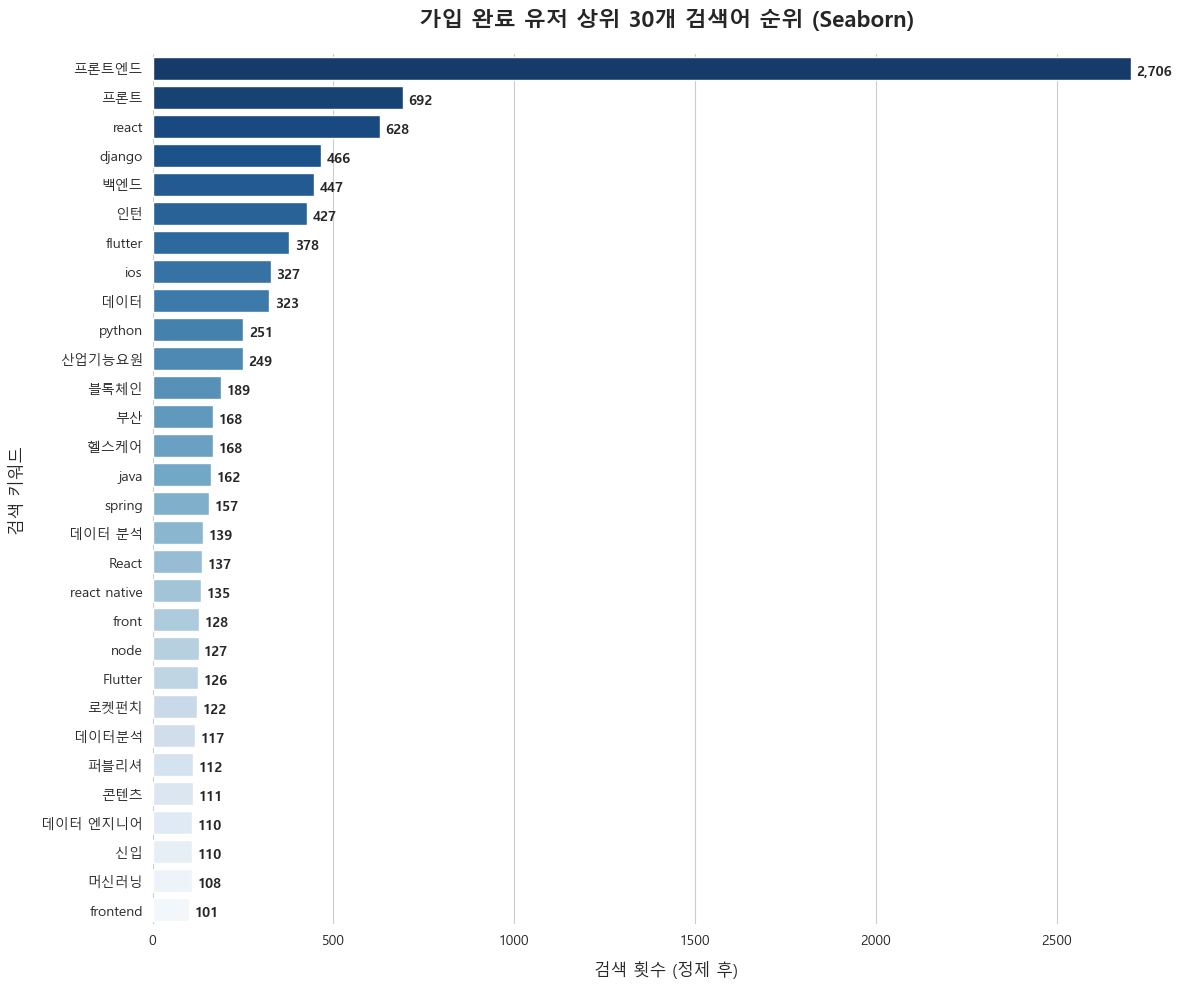

In [11]:
# 1. 윈도우 한글 깨짐 방지 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 시각화할 상위 30개 데이터 추출
df_top30 = search_rank.head(30)

# 3. 그래프 크기 및 스타일 지정
plt.figure(figsize=(12, 10))
sns.set_style("whitegrid") # 깔끔한 격자 배경 스타일 적용
plt.rc('font', family='Malgun Gothic') # 스타일 적용 후 한글 폰트 재지정

# 4. Seaborn 가로 바 차트 그리기
# 'Blues_r' 펄레트를 쓰면 1위부터 아래로 갈수록 색상이 서서히 연해집니다.
ax = sns.barplot(
    x='search_count', 
    y='search_keyword', 
    data=df_top30, 
    palette='Blues_r'
)

# 5. 바(Bar) 끝에 정확한 수치 데이터 표기하기 (텍스트 주석 추가)
for p in ax.patches:
    width = p.get_width()
    # 바의 오른쪽 끝에서 약간 띄운 위치에 숫자 표기
    ax.text(
        width + 15, 
        p.get_y() + p.get_height()/2 + 0.1, 
        f'{int(width):,}', 
        ha="left", 
        va="center", 
        fontsize=10, 
        weight='bold'
    )

# 6. 축 이름 및 제목 정리
plt.title('가입 완료 유저 상위 30개 검색어 순위 (Seaborn)', fontsize=16, pad=20, weight='bold')
plt.xlabel('검색 횟수 (정제 후)', fontsize=12, labelpad=10)
plt.ylabel('검색 키워드', fontsize=12, labelpad=10)

# 축 테두리 깔끔하게 정리
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## 2. 가입 이후 지원 활동 분석

In [12]:
# 로그 속 지원 퍼널
query = post_signup_cte + """
, job_view_users AS (
    SELECT DISTINCT user_uuid
    FROM post_signup_logs
    WHERE url_path LIKE '%%jobs%%'
       OR url_path LIKE '%%job%%'
),

apply_page_users AS (
    SELECT DISTINCT user_uuid
    FROM post_signup_logs
    WHERE url_path LIKE '%%apply%%'
       OR url_path LIKE '%%application%%'
)

SELECT
    -- 가입 완료 유저
    (SELECT COUNT(DISTINCT user_uuid) FROM step3_done_users) AS signup_users,

    -- 공고 조회 로그 유저
    (SELECT COUNT(DISTINCT user_uuid) FROM job_view_users) AS job_view_users,

    -- 지원 페이지 진입 로그 유저
    (SELECT COUNT(DISTINCT user_uuid) FROM apply_page_users) AS apply_page_users,

    -- 실제 지원 유저
    (SELECT COUNT(DISTINCT user_uuid) FROM application_users) AS application_users;
"""

apply_funnel_df = pd.read_sql(query, engine)
apply_funnel_df

### 2-1. 지원 퍼널 (공고조회 → 지원페이지 → 실제 지원)

In [13]:
# 전환율
funnel_viz_df = pd.DataFrame({
    'step': ['가입 완료', '공고 조회', '지원 페이지', '실제 지원'],
    'users': [
        apply_funnel_df.loc[0, 'signup_users'],
        apply_funnel_df.loc[0, 'job_view_users'],
        apply_funnel_df.loc[0, 'apply_page_users'],
        apply_funnel_df.loc[0, 'application_users']
    ]
})

# 가입 완료 대비 전환율
funnel_viz_df['conversion_rate'] = round(
    funnel_viz_df['users']
    / funnel_viz_df.loc[0, 'users']
    * 100,
    1
)

# 직전 단계 대비 전환율
funnel_viz_df['step_conversion_rate'] = round(
    funnel_viz_df['users']
    / funnel_viz_df['users'].shift(1)
    * 100,
    1
)

funnel_viz_df.loc[0, 'step_conversion_rate'] = 100

funnel_viz_df

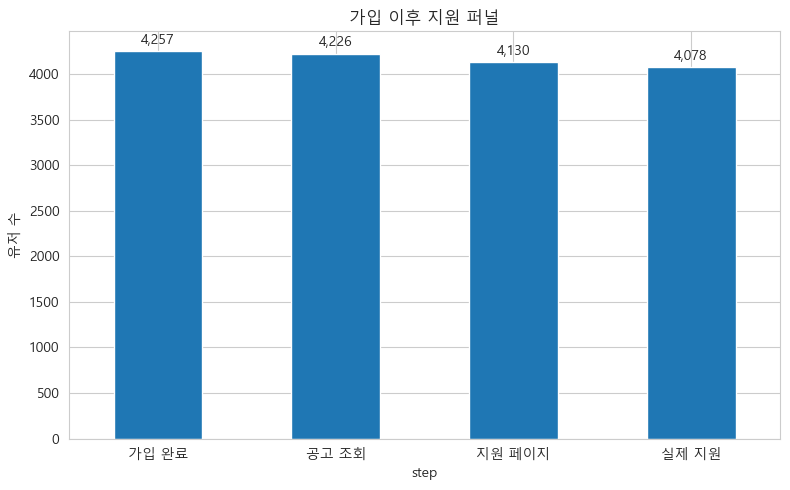

In [14]:
# 시각화 (funnel_viz_df는 위 셀에서 이미 계산됨)
ax = funnel_viz_df.plot(
    x='step',
    y='users',
    kind='bar',
    legend=False,
    figsize=(8, 5),
    title='가입 이후 지원 퍼널'
)

ax.tick_params(axis='x', rotation=0)
ax.set_ylabel('유저 수')

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3)

plt.tight_layout()
plt.show()


### 해석
- 지원 퍼널 이탈이 적음

### 2-2. 가입 후 첫 지원까지 소요 시간 분포

In [15]:
query = application_users_cte + """
SELECT
    d.user_uuid,
    d.done_time AS signup_time,
    MIN(a.first_apply_time) AS first_apply_time,
    TIMESTAMPDIFF(
        HOUR,
        d.done_time,
        MIN(a.first_apply_time)
    ) AS hours_to_apply
FROM step3_done_users d
JOIN application_users a
    ON d.user_uuid = a.user_uuid
GROUP BY d.user_uuid, d.done_time
"""

time_to_apply = pd.read_sql(query, engine)

time_to_apply['group'] = pd.cut(
    time_to_apply['hours_to_apply'],
    bins=[-1, 24, 24*7, 24*30, 24*90, float('inf')],
    labels=['1일 이내', '1주 이내', '1개월 이내', '3개월 이내', '3개월 초과']
)

print(time_to_apply['hours_to_apply'].describe())

print(
    time_to_apply['group']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .sort_index()
)

print(
    time_to_apply['hours_to_apply'].quantile(
        [0.5, 0.75, 0.9, 0.95, 0.99]
    )
)

count    4,078.00
mean     1,492.75
std      2,677.51
min          0.00
25%         15.00
50%        318.00
75%      1,514.00
max     16,310.00
Name: hours_to_apply, dtype: float64
group
1일 이내    27.80
1주 이내    12.00
1개월 이내   24.80
3개월 이내   14.90
3개월 초과   20.60
Name: proportion, dtype: float64
0.50      318.00
0.75    1,514.00
0.90    4,925.50
0.95    7,780.20
0.99   12,510.68
Name: hours_to_apply, dtype: float64


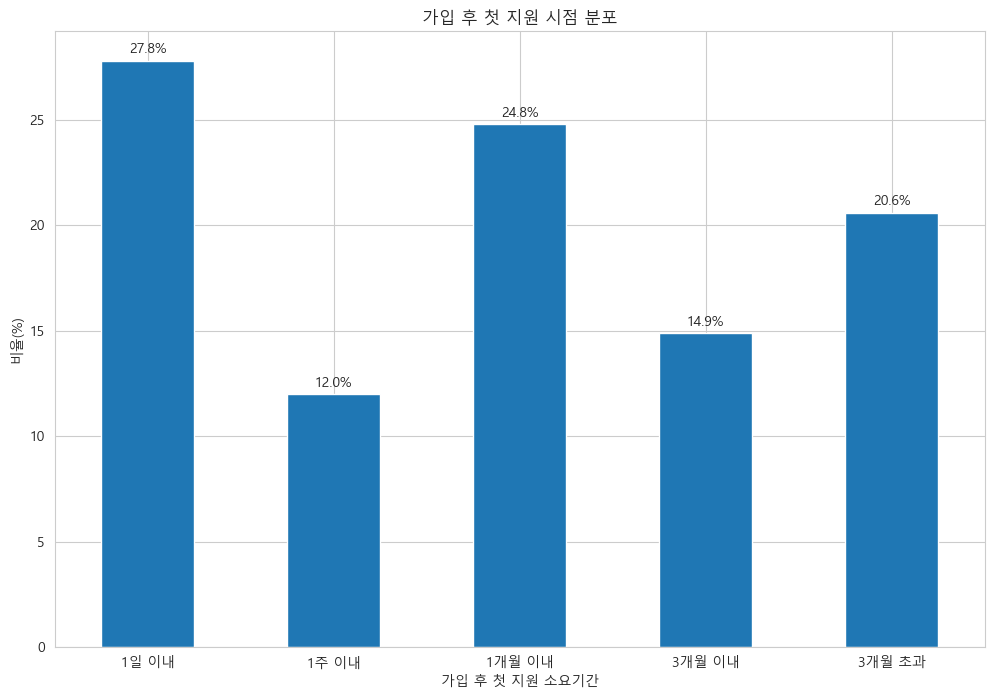

In [16]:
group_rate = (
    time_to_apply['group']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .sort_index()
)

plt.figure(figsize=(12,8))

ax = group_rate.plot(kind='bar')

plt.xlabel('가입 후 첫 지원 소요기간')
plt.ylabel('비율(%)')
plt.title('가입 후 첫 지원 시점 분포')
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3
    )

plt.show()

### 해석
- 가입 후 첫 지원까지의 소요 시간
    - 25% : 0.6일
    - 중앙값 : 13.3일 (약 2주)
    - 평균 : 62.2일(약 2개월)
    - 최대값 : 679.6일(1년 10개월)
    - 분포 : 오른쪽으로 매우 긴 형태
- 구간별 분포
    - 가입자의 약 65% : 가입 후 1개월 내 첫 지원
    - 가입자의 약 80% : 가입 후 3개월 내 첫 지원
    - 3개월 초과 가입자 : 20.6% 로, 5명 중 1명은 가입 -> 수 개월 후 지원하는 패턴
        - 예측 : 이력서 보관용 가입, 취업 준비 단계 가입, 휴면 후 재방문
- 1일 이내, 1주 이내 많은것은 -> 가입 전에 공고 확인 후 가입하자마자 지원

### 2-3. 첫 행동 유형 분포 (프로필편집 vs 공고조회 vs 검색 등)

In [17]:
query = post_signup_cte + """
, first_action AS (
    SELECT
        user_uuid,
        url_path,
        timestamp,
        ROW_NUMBER() OVER(
            PARTITION BY user_uuid
            ORDER BY timestamp
        ) AS rn
    FROM post_signup_logs
),

first_action_type AS (
    SELECT
        user_uuid,
        CASE
            WHEN url_path LIKE '%%jobs%%' AND url_path LIKE '%%apply%%'
                THEN '지원'
            WHEN url_path LIKE '%%jobs%%'
                THEN '공고조회'
            WHEN url_path LIKE '%%companies%%'
                THEN '기업조회'
            WHEN url_path LIKE '%%bookmark%%'
                THEN '북마크'
            WHEN url_path LIKE '%%search%%'
              OR url_path LIKE '%%suggest%%'
                THEN '검색'
            WHEN url_path LIKE '%%users%%'
              OR url_path LIKE '%%@user_id%%'
              OR url_path LIKE '%%resume%%'
              OR url_path LIKE '%%profile%%'
              OR url_path LIKE '%%template%%'
              OR url_path LIKE '%%experience%%'
                THEN '프로필편집'
            WHEN url_path LIKE '%%recommend%%'
                THEN '추천'
            ELSE '기타'
        END AS action_type
    FROM first_action
    WHERE rn = 1
)

SELECT
    action_type,
    COUNT(*) AS users,
    ROUND(
        COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (),
        1
    ) AS ratio
FROM first_action_type
GROUP BY action_type
ORDER BY users DESC;
"""

first_after_signup_df = pd.read_sql(query, engine)
first_after_signup_df

### 해석
- 대부분의 유저는 가입 이후 즉시 지원하지 않는 경향을 보임
    - 가입 → 준비 → 탐색 → 지원 흐름
- 1위 : 프로필편집(1,520) 
- 2위 : 공고조회(1,382)
- 3위 : 검색(579)
- 6위 : 지원(6)
- 7위 : 북마크(1)

### 2-4. 첫 행동 유형별 이후 지원 행동 비교
- 프로필 편집 유저(1위)와 공고조회 유저(2위)의 지원행동 비교분석 

In [18]:
query = post_signup_cte + """
, first_action AS (
    SELECT
        user_uuid,
        done_time,
        timestamp,
        url_path,
        ROW_NUMBER() OVER(
            PARTITION BY user_uuid
            ORDER BY timestamp
        ) AS rn
    FROM post_signup_logs
),

first_action_type AS (
    SELECT
        user_uuid,
        done_time,
        CASE
            WHEN url_path LIKE '%%jobs%%'
                THEN '공고조회'
            WHEN url_path LIKE '%%users%%'
              OR url_path LIKE '%%@user_id%%'
              OR url_path LIKE '%%resume%%'
              OR url_path LIKE '%%profile%%'
              OR url_path LIKE '%%template%%'
              OR url_path LIKE '%%experience%%'
                THEN '프로필편집'
        END AS first_action
    FROM first_action
    WHERE rn = 1
),

application_stats AS (
    SELECT
        f.user_uuid,
        f.first_action,

        -- 유저 전체 지원 횟수
        COALESCE(MAX(a.apply_total), 0) AS apply_count,

        -- 가입 완료 후 첫 지원까지 걸린 시간
        TIMESTAMPDIFF(
            HOUR,
            f.done_time,
            MIN(a.first_apply_time)
        ) AS apply_lead_hours

    FROM first_action_type f
    LEFT JOIN application_users a
        ON f.user_uuid = a.user_uuid
    WHERE f.first_action IS NOT NULL
    GROUP BY
        f.user_uuid,
        f.first_action,
        f.done_time
)

SELECT *
FROM application_stats;
"""

application_stats_df = pd.read_sql(query, engine)
# (데이터 보호: 원본 미리보기 출력 제거)
# application_stats_df


In [19]:
# 평균, 중앙값, 최대값 계산
summary_df = (
    application_stats_df
    .groupby('first_action')
    .agg(
        users=('user_uuid', 'count'),
        applied_users=('apply_count', lambda x: (x > 0).sum()),
        apply_rate=('apply_count', lambda x: round((x > 0).mean() * 100, 1)),

        avg_apply_count=('apply_count', 'mean'),
        median_apply_count=('apply_count', 'median'),
        max_apply_count=('apply_count', 'max'),

        avg_apply_lead_hours=('apply_lead_hours', 'mean')
    )
    .reset_index()
)

summary_df

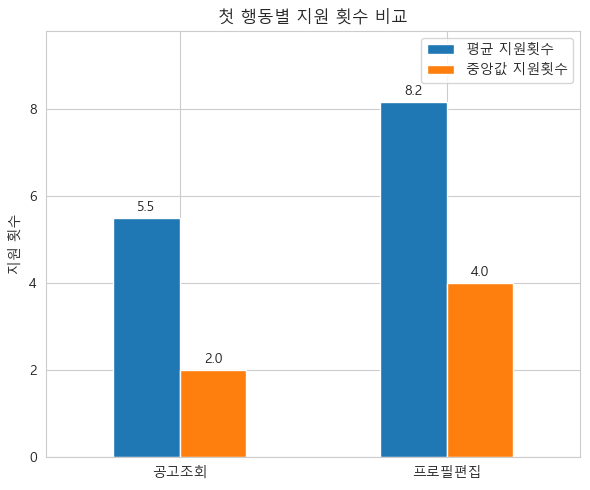

In [20]:
# 시각화
# 첫 행동별 지원 횟수 비교


plot_df = summary_df.set_index('first_action')[
    ['avg_apply_count', 'median_apply_count']
]

ax = plot_df.plot(
    kind='bar',
    figsize=(6, 5)
)

ax.set_title('첫 행동별 지원 횟수 비교')
ax.set_xlabel('')
ax.set_ylabel('지원 횟수')
ax.tick_params(axis='x', rotation=0)

# 막대 위 수치 표시
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f',
        padding=3
    )

# 레이블 잘림 방지
plt.tight_layout()

# y축 여유 공간 추가
ax.set_ylim(
    0,
    plot_df.max().max() * 1.2
)
# 범례 한글
ax.legend(
    ['평균 지원횟수', '중앙값 지원횟수']
)
plt.show()

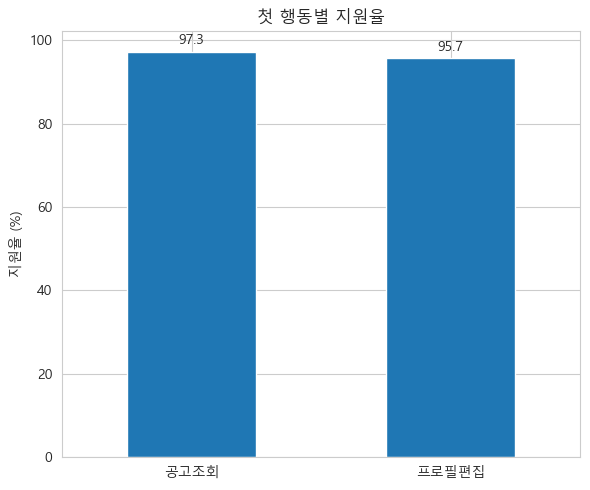

In [21]:
# 시각화
# 첫 행동별 지원율 비교
ax = summary_df.plot(
    x='first_action',
    y='apply_rate',
    kind='bar',
    legend=False,
    figsize=(6, 5)
)

ax.set_title('첫 행동별 지원율')
ax.set_xlabel('')
ax.set_ylabel('지원율 (%)')
ax.tick_params(axis='x', rotation=0)

# 막대 위 수치 표시
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f',
        padding=3
    )

# 레이블 잘림 방지
plt.tight_layout()


plt.show()

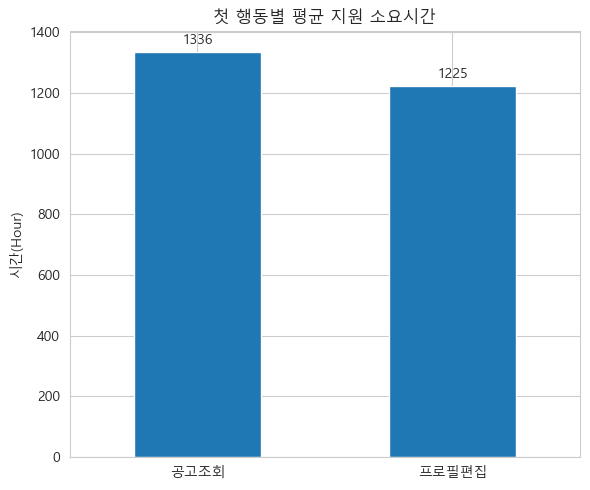

In [22]:
# 시각화
# 첫 행동별 평균 지원 소요시간
ax = summary_df.plot(
    x='first_action',
    y='avg_apply_lead_hours',
    kind='bar',
    legend=False,
    figsize=(6, 5)
)

ax.set_title('첫 행동별 평균 지원 소요시간')
ax.set_xlabel('')
ax.set_ylabel('시간(Hour)')
ax.tick_params(axis='x', rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

### 해석
- 가입 직후 프로필을 먼저 편집한 사용자는 공고를 먼저 조회한 사용자보다 평균 지원 횟수(8.16회 vs 5.49회)가 높게 나타남
- 중앙값 역시 4회와 2회로 2배 차이
- 프로필 정비 행동이 이후 적극적인 구직 활동과 연관될 가능성
- (지원율, 지원까지 걸린 시간은 크게 차이 안남)

### 2-5. 유저별 지원 횟수 분포 및 세그먼트

In [23]:
query = application_users_cte + """
SELECT
    d.user_uuid,
    COALESCE(a.apply_total, 0) AS apply_count_after_signup
FROM step3_done_users d
LEFT JOIN (
    SELECT
        user_uuid,
        MAX(apply_total) AS apply_total
    FROM application_users
    GROUP BY user_uuid
) a
    ON d.user_uuid = a.user_uuid
"""

apply_dist = pd.read_sql(query, engine)

apply_dist['segment'] = pd.cut(
    apply_dist['apply_count_after_signup'],
    bins=[-1, 0, 1, 4, float('inf')],
    labels=[
        '미지원(0회)',
        '1회 지원',
        '2~4회 지원',
        '5회 이상'
    ]
)

segment_ratio = (
    apply_dist['segment']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .sort_index()
)

print(segment_ratio)

segment
미지원(0회)    4.20
1회 지원     33.30
2~4회 지원   26.00
5회 이상     36.50
Name: proportion, dtype: float64


In [24]:
apply_dist['apply_count_after_signup'].describe()
# 카운트 횟수 : 2457 이유 = 미지원(0회) 포함

### 해석
- 95.8% 가입 후 최소 1회 이상 지원
    - 5회 이상 : 36.5% 
        - 가입 -> 여러 공고 탐색 -> 반복 지원 패턴이 많음
    - 평균 : 6.96회
    - 중앙값 : 3회
        - 일부 유저의 이상치로 평균을 끌어올리고 있음
    - 사분위수
        - 25 % : 1회
        - 50 % : 3회
        - 75 % : 8회

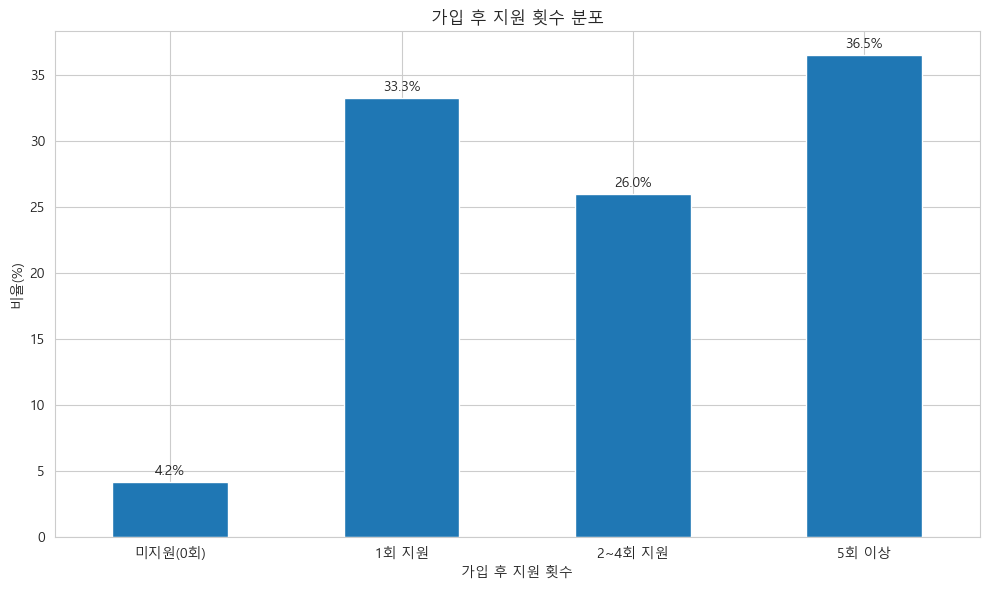

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

segment_ratio.plot(
    kind='bar',
    ax=ax
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3
    )

ax.set_xlabel('가입 후 지원 횟수')
ax.set_ylabel('비율(%)')
ax.set_title('가입 후 지원 횟수 분포')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 3. 북마크 행동 분석

### 3-1. 북마크 활성 유저 비율 및 가입 후 첫 북마크까지 소요 시간

In [26]:
# 1. 회원가입 완료 로그만 필터링 (가입 완료 URL + 성공 로그)
df_signup_logs = df_full_logs[
    (df_full_logs['URL'].str.contains('signup/step3/done', na=False)) &
    (df_full_logs['response_code'].astype(str).str.strip() == '200')
].copy()

# 2. 유저별로 '가입 완료 로그'가 찍힌 최초의 시간을 가입 완료 시간으로 정의
df_signup_time = df_signup_logs.groupby('user_uuid').agg(
    signup_completed_at=('timestamp', 'min')
).reset_index()

# 3. 시간 컬럼 데이터타입 정리 (타임존 제거로 통일)
df_signup_time['signup_completed_at'] = pd.to_datetime(df_signup_time['signup_completed_at']).dt.tz_localize(None)

# 결과 확인
# (데이터 보호: 원본 미리보기 출력 제거)
# df_signup_time


In [27]:
REFRESH = False
CACHE_FILE = "_cache/df_bookmark_left_joined.pkl"

query = """
WITH logs AS (
    SELECT user_uuid, timestamp, URL, response_code, method
    FROM log_2022
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400, 404, 500) -- 모든 단계 공통: 에러 제외

    UNION ALL

    SELECT user_uuid, timestamp, URL, response_code, method
    FROM log_2023
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400, 404, 500) -- 모든 단계 공통: 에러 제외
),

step_detail_users AS (
    SELECT
        user_uuid,
        MIN(timestamp) AS detail_time
    FROM logs
    WHERE URL LIKE '%%signup/detail%%'
    GROUP BY user_uuid
),

step1_users AS (
    SELECT
        l.user_uuid,
        MIN(l.timestamp) AS step1_time
    FROM logs l
    INNER JOIN step_detail_users d
       ON l.user_uuid = d.user_uuid
      AND l.timestamp >= d.detail_time
    WHERE l.URL LIKE '%%signup/step1%%'
    GROUP BY l.user_uuid
),

step2_users AS (
    SELECT
        l.user_uuid,
        MIN(l.timestamp) AS step2_time
    FROM logs l
    INNER JOIN step1_users s1
       ON l.user_uuid = s1.user_uuid
      AND l.timestamp >= s1.step1_time
    WHERE l.URL LIKE '%%signup/step2%%'
    GROUP BY l.user_uuid
),

step3_done_users AS (
    SELECT
        l.user_uuid,
        MIN(l.timestamp) AS done_time
    FROM logs l
    INNER JOIN step2_users s2
       ON l.user_uuid = s2.user_uuid
      AND l.timestamp >= s2.step2_time
    WHERE l.URL LIKE '%%signup/step3/done%%'
      AND l.response_code = 200 -- ★ 스텝3 완료는 오직 200인 것만 인정
    GROUP BY l.user_uuid
),

-- ★ 요청하신 유저별/공고별 최초 북마크 시간 및 인당 총 북마크수(bm_cnt) 집계 단계
bookmark_users AS (
    SELECT
        d.user_uuid,
        jb.job_uuid,
        MIN(jb.cdate) AS first_bm_time,
        COUNT(*) OVER (PARTITION BY d.user_uuid) AS bm_cnt
    FROM step3_done_users d
    INNER JOIN JobBookmark jb
       ON d.user_uuid = jb.user_uuid
      AND jb.cdate >= d.done_time
    GROUP BY d.user_uuid, jb.job_uuid
)

-- 최종 결과: 가입 후 북마크 기록에 job 테이블의 모든 정보 결합 (LEFT JOIN)
SELECT 
    b.user_uuid,
    b.job_uuid,
    b.first_bm_time,              -- 가입 후 실제 최초 북마크 일시
    b.bm_cnt,                     -- 해당 유저가 가입 후 누른 총 북마크 개수
    j.cdate,                      -- 채용 공고 올라온 날짜
    j.mdate,                      -- 채용 공고 마지막 수정일
    j.job_field,                  -- 직무 분야
    j.career_type_string,         -- 요구 경력 유형
    j.start_date,                 -- 공고 시작일
    j.end_date,                   -- 공고 마감일
    j.allow_remote,               -- 원격 근무 가능 여부
    j.can_show_salary,            -- 연봉 공개 여부
    j.company_uuid                -- 기업 id
FROM bookmark_users b
LEFT JOIN job j 
       ON TRIM(CAST(b.job_uuid AS CHAR)) = TRIM(CAST(j.job_uuid AS CHAR)); -- 타입 불일치 방지 형변환
"""

# 3. 캐싱 블록 실행
if REFRESH or not os.path.exists(CACHE_FILE):
    df_bookmark_left_joined = pd.read_sql(query, engine)
    df_bookmark_left_joined.to_pickle(CACHE_FILE)
else:
    df_bookmark_left_joined = pd.read_pickle(CACHE_FILE)

# 4. 결과 데이터프레임 확인 (모든 컬럼이 잘 나오는지 확인해 보세요!)
# (데이터 보호: 원본 미리보기 출력 제거)
# df_bookmark_left_joined


In [28]:
# 1. 북마크를 최소 한 번이라도 한 고유(Distinct) 유저 수 계산
# (이미 가입 후 북마크 기록만 모여 있으므로 데이터프레임 내 user_uuid의 유니크한 개수를 세면 됩니다)
active_user_count = df_bookmark_left_joined['user_uuid'].nunique()

# 2. 유저당 평균 북마크 수 계산
# 각 유저의 고유한 bm_cnt(해당 유저의 총 북마크 수) 값들의 평균을 구합니다.
# 한 유저가 여러 공고를 북마크하여 행이 중복되어 있으므로, 유저별로 1개씩만 drop_duplicates하여 평균을 냅니다.
df_user_unique_bm = df_bookmark_left_joined.drop_duplicates(subset=['user_uuid'])
average_bookmarks_per_user = df_user_unique_bm['bm_cnt'].mean()

# 3. 데이터 신뢰도를 높이기 위한 중앙값(Median)과 최댓값(Max)도 함께 계산
median_bookmarks_per_user = df_user_unique_bm['bm_cnt'].median()
max_bookmarks_per_user = df_user_unique_bm['bm_cnt'].max()

# 4. 결과 출력
print("==================================================")
print(f"👥 가입 후 북마크를 1회 이상 누른 고유 유저 수: {active_user_count:,}명")
print(f"📈 활성 유저 1인당 평균 북마크 생성 개수: {average_bookmarks_per_user:.2f}개")
print(f"📊 활성 유저 북마크 개수 중앙값(Median): {median_bookmarks_per_user:.1f}개")
print(f"🔥 한 유저가 기록한 최다 북마크 개수: {max_bookmarks_per_user:,}개")
print("==================================================")

👥 가입 후 북마크를 1회 이상 누른 고유 유저 수: 2,065명
📈 활성 유저 1인당 평균 북마크 생성 개수: 8.97개
📊 활성 유저 북마크 개수 중앙값(Median): 4.0개
🔥 한 유저가 기록한 최다 북마크 개수: 238개


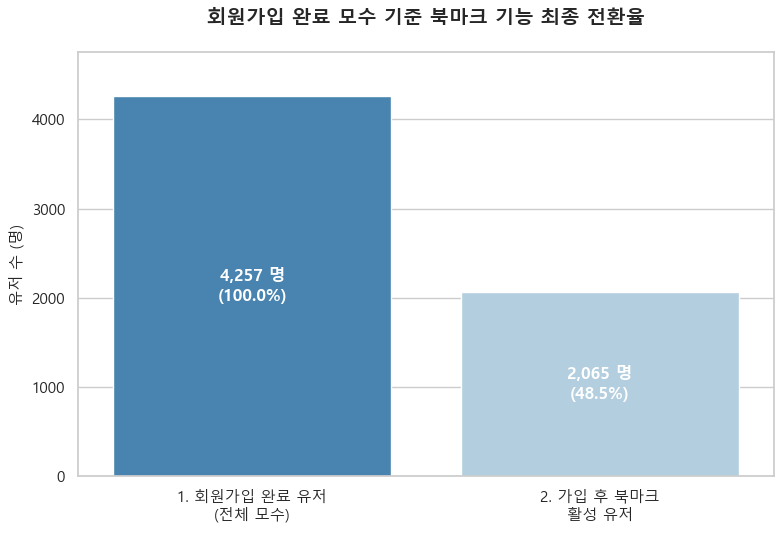

In [29]:
# 한글 깨짐 방지 및 스타일 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)
sns.set_theme(style="whitegrid", font="Malgun Gothic")

# 가입 완료 유저 총수 (Acquisition 분석 기준)
total_signup = 4257
non_active_user = total_signup - active_user_count

# 데이터 구축
categories = ['1. 회원가입 완료 유저\n(전체 모수)', '2. 가입 후 북마크\n활성 유저']
counts = [total_signup, active_user_count]

plt.figure(figsize=(8, 5.5))

# 바 차트 시각화
ax = sns.barplot(x=categories, y=counts, palette='Blues_r', hue=categories, legend=False)

# 바 상단에 수치 및 전체 대비 비율(%) 표기
for i, p in enumerate(ax.patches):
    height = p.get_height()
    percentage = (height / total_signup) * 100
    
    ax.annotate(f"{int(height):,} 명\n({percentage:.1f}%)", 
                (p.get_x() + p.get_width() / 2., height / 2 if height > 1000 else height + 100), 
                ha='center', va='center', 
                fontsize=12, color='white' if height > 1000 else 'black', weight='bold')

plt.title('회원가입 완료 모수 기준 북마크 기능 최종 전환율', fontsize=14, weight='bold', pad=20)
plt.ylabel('유저 수 (명)', fontsize=11)
plt.ylim(0, total_signup + 500)

plt.tight_layout()
plt.show()

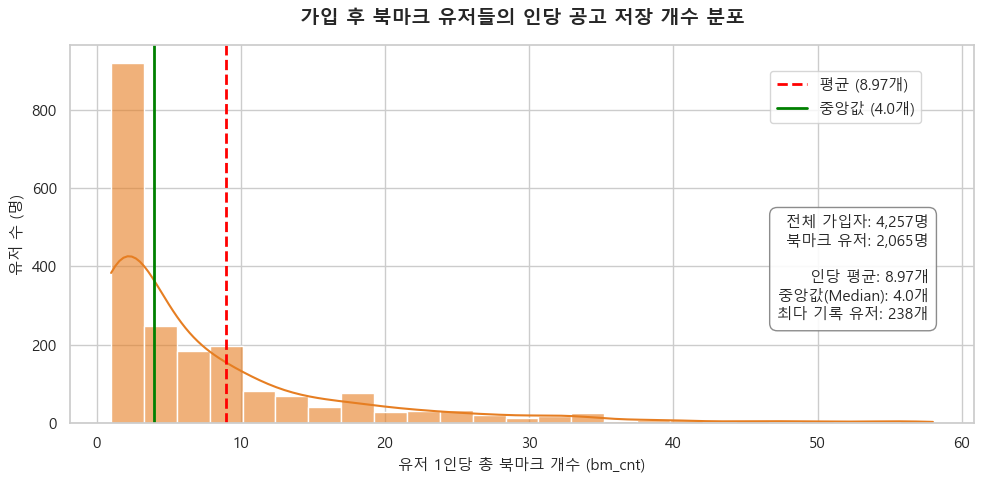

In [30]:
# 스타일 설정
plt.rc('font', family='Malgun Gothic')
sns.set_theme(style="whitegrid", font="Malgun Gothic")

plt.figure(figsize=(10, 5))

# 유저별 고유 bm_cnt 데이터 세트 추출 (중복 제거된 데이터프레임 활용)
# 상위 1% 극단치 유저로 인해 그래프가 찌그러지는 것을 방지하기 위해 99% 분위수 구간만 시각화합니다.
q_99 = df_user_unique_bm['bm_cnt'].quantile(0.99)
df_filtered_dist = df_user_unique_bm[df_user_unique_bm['bm_cnt'] <= q_99]

# 히스토그램 및 밀도 곡선(KDE) 그리기
sns.histplot(data=df_filtered_dist, x='bm_cnt', bins=25, kde=True, color='#e67e22', alpha=0.6)

# 앞서 구한 평균값과 중앙값 세로선 표시
plt.axvline(average_bookmarks_per_user, color='red', linestyle='--', linewidth=2, label=f'평균 ({average_bookmarks_per_user:.2f}개)')
plt.axvline(median_bookmarks_per_user, color='green', linestyle='-', linewidth=2, label=f'중앙값 ({median_bookmarks_per_user:.1f}개)')

# 통계 요약 박스 배치
stats_summary = f"전체 가입자: {total_signup:,}명\n북마크 유저: {active_user_count:,}명\n\n인당 평균: {average_bookmarks_per_user:.2f}개\n중앙값(Median): {median_bookmarks_per_user:.1f}개\n최다 기록 유저: {max_bookmarks_per_user:,}개"
plt.text(0.95, 0.55, stats_summary, transform=plt.gca().transAxes, 
         fontsize=11, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))

plt.title('가입 후 북마크 유저들의 인당 공고 저장 개수 분포', fontsize=14, weight='bold', pad=15)
plt.xlabel('유저 1인당 총 북마크 개수 (bm_cnt)', fontsize=11)
plt.ylabel('유저 수 (명)', fontsize=11)
plt.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95))

plt.tight_layout()
plt.show()

In [31]:
# 1. 시점 비교 및 계산을 위해 날짜 컬럼 형식을 타임존 없는 datetime으로 통일
df_bookmark_left_joined['first_bm_time'] = pd.to_datetime(df_bookmark_left_joined['first_bm_time']).dt.tz_localize(None)
df_signup_time['signup_completed_at'] = pd.to_datetime(df_signup_time['signup_completed_at']).dt.tz_localize(None)

# 2. 북마크 마스터 테이블에 유저별 가입 완료 시간 결합
df_first_action = pd.merge(
    df_bookmark_left_joined, 
    df_signup_time, 
    on='user_uuid', 
    how='left'
)

# 3. [SQL 쿼리에서 이미 가입 후 데이터만 필터링 완료되었으므로 1차 필터링 생략]

# 4. ★ 핵심: 유저별로 가입 후 "가장 처음(최초)" 누른 북마크 시간(min) 딱 1건씩만 추출
# 중복이 제거되면서 순수 가입 후 북마크 활성자 수(2,066명)로 압축됩니다.
df_user_first_bookmark = df_first_action.groupby('user_uuid').agg(
    first_bookmark_at=('first_bm_time', 'min'),
    signup_completed_at=('signup_completed_at', 'first')
).reset_index()

# 5. 가입 완료 시점과 첫 북마크 시점 사이의 시차(Time Delta) 계산
# (1) 초 단위 계산 후 시간(Hours) 단위로 변환
df_user_first_bookmark['hours_to_first_bookmark'] = (
    df_user_first_bookmark['first_bookmark_at'] - df_user_first_bookmark['signup_completed_at']
).dt.total_seconds() / 3600.0

# (2) 일(Days) 단위로도 변환
df_user_first_bookmark['days_to_first_bookmark'] = df_user_first_bookmark['hours_to_first_bookmark'] / 24.0


# 6. 결과 출력 및 검증
avg_hours = df_user_first_bookmark['hours_to_first_bookmark'].mean()
median_hours = df_user_first_bookmark['hours_to_first_bookmark'].median()

print("==================================================")
print(f"⏱️ 대상 유저 수 (가입 후 북마크 활성자): {len(df_user_first_bookmark):,}명")
print("==================================================")
print(f"🔹 가입 후 첫 북마크까지 걸린 평균 시간: {avg_hours:.1f}시간 (약 {avg_hours/24:.1f}일)")
print(f"🔹 가입 후 첫 북마크까지 걸린 시간 중앙값: {median_hours:.1f}시간 (약 {median_hours/24:.1f}일)")
print("==================================================")

# 분포 시각화를 위해 계산용 df 보관
# (데이터 보호: 원본 미리보기 출력 제거)
# df_user_first_bookmark


⏱️ 대상 유저 수 (가입 후 북마크 활성자): 2,065명
🔹 가입 후 첫 북마크까지 걸린 평균 시간: 1710.9시간 (약 71.3일)
🔹 가입 후 첫 북마크까지 걸린 시간 중앙값: 354.0시간 (약 14.8일)


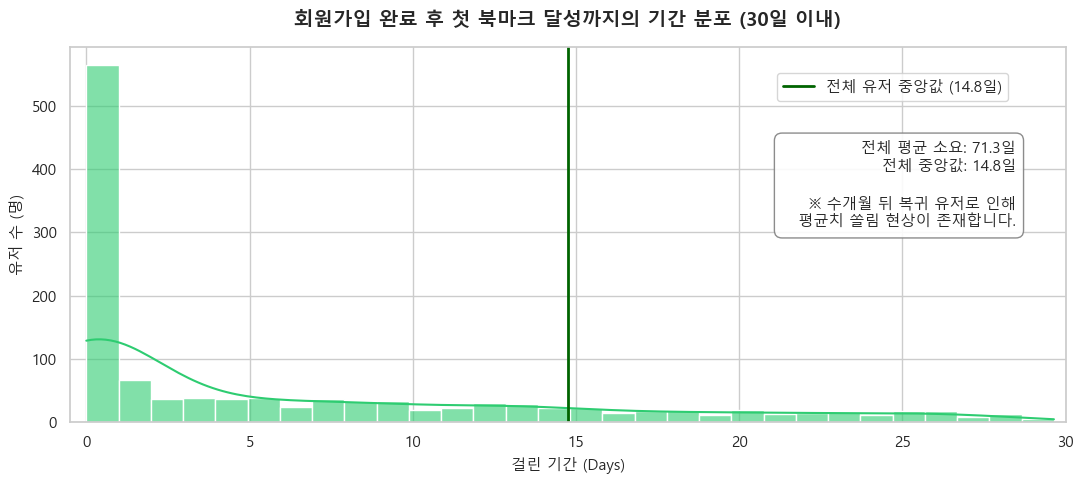

In [32]:
# 한글 깨짐 방지 및 스타일 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)
sns.set_theme(style="whitegrid", font="Malgun Gothic")

# 앞서 연산된 통계 변수 재정의 (일 단위 기준 변환)
avg_days = df_user_first_bookmark['days_to_first_bookmark'].mean()
median_days = df_user_first_bookmark['days_to_first_bookmark'].median()

plt.figure(figsize=(11, 5))

# 가입 후 한 달(30일) 이내에 첫 행동을 완료한 진성 활성 유저 군집만 필터링
df_under_30d = df_user_first_bookmark[df_user_first_bookmark['days_to_first_bookmark'] <= 30]

# 히스토그램 분포 차트 그리기
sns.histplot(data=df_under_30d, x='days_to_first_bookmark', bins=30, kde=True, color='#2ecc71', alpha=0.6)

# 왜곡 구간 밖의 전체 데이터 통계치를 선 및 텍스트 박스로 매칭
plt.axvline(median_days, color='darkgreen', linestyle='-', linewidth=2, label=f'전체 유저 중앙값 ({median_days:.1f}일)')

# 통계 요약 지표 리포트 텍스트 배치
stats_report = (
    f"전체 평균 소요: {avg_days:.1f}일\n"
    f"전체 중앙값: {median_days:.1f}일\n\n"
    f"※ 수개월 뒤 복귀 유저로 인해\n"
    f"   평균치 쏠림 현상이 존재합니다."
)
plt.text(0.95, 0.75, stats_report, transform=plt.gca().transAxes, 
         fontsize=11, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))

plt.title('회원가입 완료 후 첫 북마크 달성까지의 기간 분포 (30일 이내)', fontsize=14, weight='bold', pad=15)
plt.xlabel('걸린 기간 (Days)', fontsize=11)
plt.ylabel('유저 수 (명)', fontsize=11)
plt.xlim(-0.5, 30)  # x축 탐색 범위를 0일부터 한 달까지로 최적화 고정
plt.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95))

plt.tight_layout()
plt.show()

In [33]:
# 1. 시점 비교를 위해 모든 날짜/시간 컬럼을 타임존 없는 datetime 형식으로 변환
date_columns = ['first_bm_time', 'start_date', 'end_date', 'cdate']
for col in date_columns:
    df_bookmark_left_joined[col] = pd.to_datetime(df_bookmark_left_joined[col]).dt.tz_localize(None)

df_signup_time['signup_completed_at'] = pd.to_datetime(df_signup_time['signup_completed_at']).dt.tz_localize(None)

# 2. 북마크 테이블에 유저별 가입 완료 시간 결합
df_anal = pd.merge(df_bookmark_left_joined, df_signup_time, on='user_uuid', how='left')

# 3. [SQL 쿼리에서 이미 가입 후 데이터만 필터링 완료되었으므로 복사본 생성 후 바로 연산 진행]
df_anal_after = df_anal.copy()

# 4. 날짜 간격(Day) 계산 컬럼 생성
# (1) 공고 시작일 ~ 북마크일
df_anal_after['days_from_start'] = (df_anal_after['first_bm_time'] - df_anal_after['start_date']).dt.days

# (2) 북마크일 ~ 공고 마감일
df_anal_after['days_to_end'] = (df_anal_after['end_date'] - df_anal_after['first_bm_time']).dt.days

# (3) 채용공고 올라온 날짜(cdate) ~ 북마크일(first_bm_time)
df_anal_after['days_from_posted'] = (df_anal_after['first_bm_time'] - df_anal_after['cdate']).dt.days


# 5. [최종 출력] 가입 후 북마크 활동 전체 평균 통계
print("==================================================")
print("🚀 [전체] 가입 후 북마크 활동 날짜 간격 평균")
print("==================================================")
print(f"🔹 공고 시작일로부터 북마크까지 걸린 평균 날짜: {df_anal_after['days_from_start'].mean():.1f}일")
print(f"🔹 북마크 시점부터 공고 마감일까지 남은 평균 날짜: {df_anal_after['days_to_end'].mean():.1f}일")
print(f"🔹 공고가 올라온 후 북마크까지 걸린 평균 날짜: {df_anal_after['days_from_posted'].mean():.1f}일")
print("================================================__")

🚀 [전체] 가입 후 북마크 활동 날짜 간격 평균
🔹 공고 시작일로부터 북마크까지 걸린 평균 날짜: 94.0일
🔹 북마크 시점부터 공고 마감일까지 남은 평균 날짜: 91.6일
🔹 공고가 올라온 후 북마크까지 걸린 평균 날짜: 161.7일
================================================__


#### 데이터 전처리 보고서: 시각화를 위한 데이터 정제

##### 1. 데이터 특성 및 이상치 발생 원인
* **상시·장기 공고**: 마감 기한이 없거나 게시된 지 수개월이 지난 공고의 존재로 인해 최대 300~500일 단위의 데이터 발생
* **관점 전환**: 이는 데이터 오염(에러)이 아닌, 상시 채용 공고를 장기 탐색하는 유저의 정상적인 비즈니스 행동 패턴(Long-tail) 분석에 필요한 수치임

##### 2. 데이터 분석 기준 (이원화 접근)
* **단기 집중 분석**: 일반 기한제 공고의 행동 패턴(Recency) 분석을 위해 `60일 이하` 구간 데이터 분리 활용
* **전체 모수 분석**: 상시 공고를 포함한 분석 시, 극단치에 취약한 평균 대신 **중앙값(Median)**을 대표 지표로 설정

##### 3. 60일 이하 데이터 정제 사유 (단기 분석용)
* **통계 왜곡 차단**: 상시 공고의 긴 리드타임이 전체 평균(`mean`)을 데이터가 없는 수개월 뒤 지점으로 끌어당기는 현상 방지
* **정합성 확보**: 일반 구직자층의 주류 행동 패턴(0~30일 이내) 중심의 실질적 지표 도출

##### 4. 보정 결과
* **모수 일치**: 통계 지표 계산 모수와 시각화 범위를 동일하게 일치시켜 분포 중심부에 평균선 위치 보정 완료

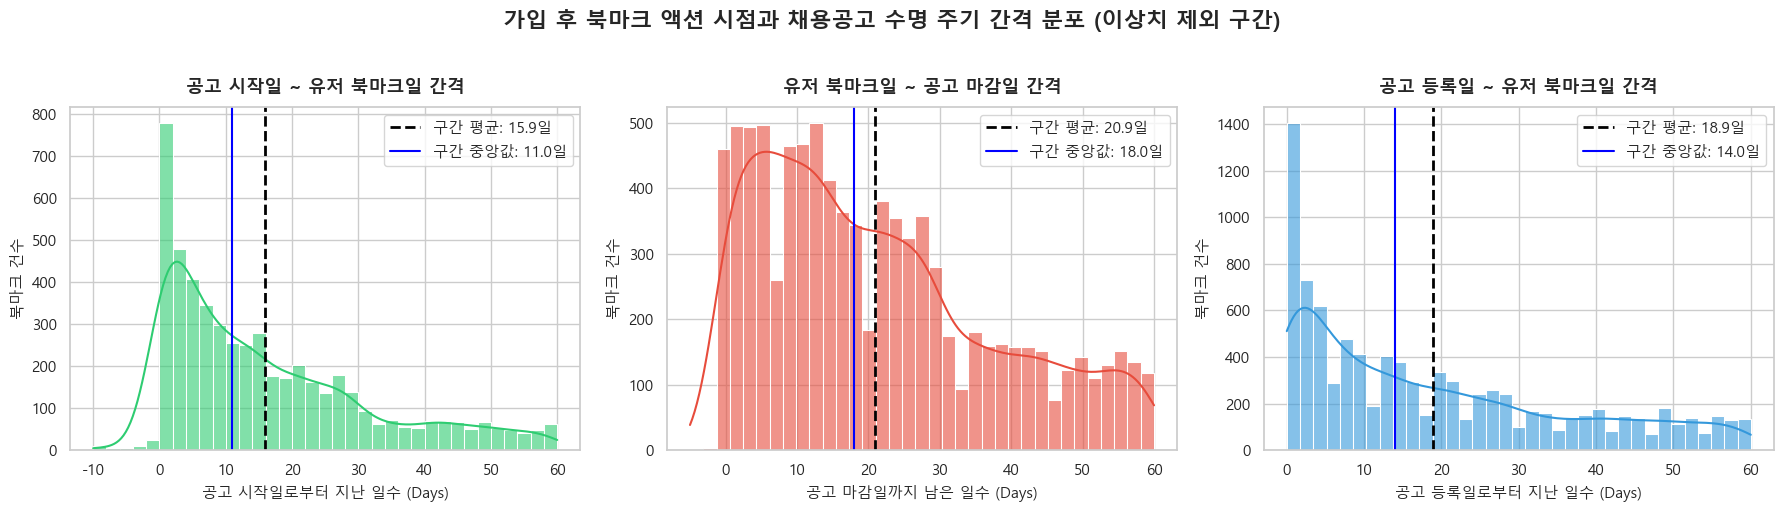

In [34]:
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)
sns.set_theme(style="whitegrid", font="Malgun Gothic")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 명확한 시점 비교를 위해 타이틀과 x축 레이블을 구체적으로 수정했습니다.
metrics = [
    ('days_from_start', '공고 시작일 ~ 유저 북마크일 간격', '#2ecc71', '공고 시작일로부터 지난 일수 (Days)'),
    ('days_to_end', '유저 북마크일 ~ 공고 마감일 간격', '#e74c3c', '공고 마감일까지 남은 일수 (Days)'),
    ('days_from_posted', '공고 등록일 ~ 유저 북마크일 간격', '#3498db', '공고 등록일로부터 지난 일수 (Days)')
]

for i, (col, title, color, xlabel) in enumerate(metrics):
    # 그래프용 필터링 수행 및 변수 저장
    df_filtered = df_anal_after[(df_anal_after[col] >= -10) & (df_anal_after[col] <= 60)]
    
    # 히스토그램 + 밀도 곡선 그리기
    sns.histplot(data=df_filtered, x=col, bins=35, kde=True, color=color, ax=axes[i], alpha=0.6)
    
    # 필터링된 데이터셋 기준 평균 및 중앙값 계산
    filtered_mean = df_filtered[col].mean()
    filtered_median = df_filtered[col].median()
    
    # 평균선(점선)과 중앙값선(실선) 표시
    axes[i].axvline(filtered_mean, color='black', linestyle='--', linewidth=2, label=f'구간 평균: {filtered_mean:.1f}일')
    axes[i].axvline(filtered_median, color='blue', linestyle='-', linewidth=1.5, label=f'구간 중앙값: {filtered_median:.1f}일')
    
    axes[i].set_title(title, fontsize=13, weight='bold', pad=10)
    axes[i].set_xlabel(xlabel, fontsize=11)
    axes[i].set_ylabel('북마크 건수', fontsize=11)
    axes[i].legend(loc='upper right')

plt.suptitle('가입 후 북마크 액션 시점과 채용공고 수명 주기 간격 분포 (이상치 제외 구간)', fontsize=16, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3-2. 북마크 여부별 지원 전환율 비교

In [35]:
query = bookmark_users_cte + """
SELECT 
    b.user_uuid,
    b.job_uuid,
    b.first_bm_time,
    b.bm_cnt,
    j.cdate,
    j.mdate,
    j.job_field,
    j.career_type_string,
    j.start_date,
    j.end_date,
    j.allow_remote,
    j.can_show_salary,
    j.company_uuid
FROM bookmark_users b
LEFT JOIN Job j 
    ON TRIM(CAST(b.job_uuid AS CHAR)) = TRIM(CAST(j.job_uuid AS CHAR))
"""

bookmark_job = pd.read_sql(query, engine)

# (데이터 보호: 원본 미리보기 출력 제거)
# bookmark_job.head()


In [36]:
query = signup_cte + """
SELECT
    d.user_uuid,
    CASE
        WHEN COUNT(DISTINCT a.application_uuid) > 0
         AND COUNT(DISTINCT b.job_uuid) > 0
            THEN '북마크+지원'

        WHEN COUNT(DISTINCT a.application_uuid) > 0
            THEN '지원만'

        WHEN COUNT(DISTINCT b.job_uuid) > 0
            THEN '북마크만'

        ELSE '가입 후 이탈'
    END AS user_segment

FROM step3_done_users d

LEFT JOIN Application a
    ON d.user_uuid = a.user_uuid
   AND a.cdate >= d.done_time

LEFT JOIN JobBookmark b
    ON d.user_uuid = b.user_uuid
   AND b.cdate >= d.done_time

GROUP BY d.user_uuid
"""

segment = pd.read_sql(query, engine)
# (데이터 보호: 원본 미리보기 출력 제거)
# segment


In [37]:
segment_summary = (
    segment['user_segment']
    .value_counts()
    .reset_index()
)

segment_summary.columns = [
    'user_segment',
    'user_count'
]

segment_summary['ratio'] = (
    segment_summary['user_count']
    / segment_summary['user_count'].sum()
    * 100
).round(1)

segment_summary

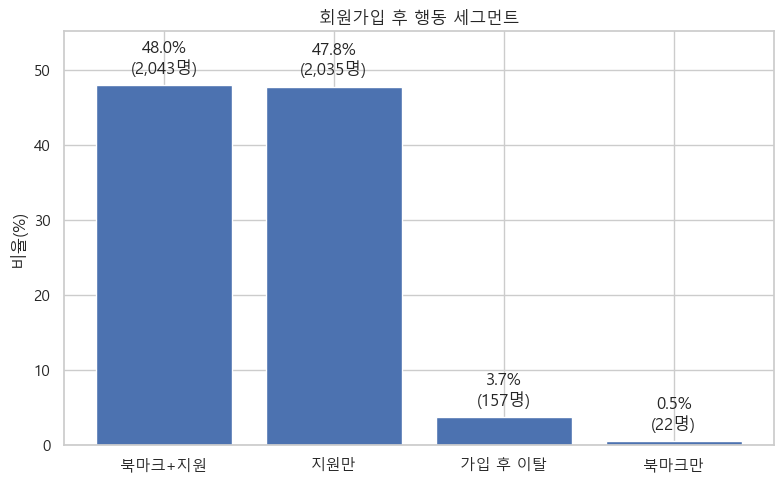

In [38]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    segment_summary['user_segment'],
    segment_summary['ratio']
)

ax.set_ylim(
    0,
    max(segment_summary['ratio']) * 1.15
)

for bar, ratio, count in zip(
    bars,
    segment_summary['ratio'],
    segment_summary['user_count']
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{ratio:.1f}%\n({count:,}명)',
        ha='center',
        va='bottom'
    )

ax.set_title('회원가입 후 행동 세그먼트')
ax.set_xlabel('')
ax.set_ylabel('비율(%)')

plt.tight_layout()
plt.show()

In [39]:
query = signup_cte + """
SELECT
    d.user_uuid,

    CASE
        WHEN COUNT(DISTINCT b.job_uuid) > 0
            THEN '북마크 있음'
        ELSE '북마크 없음'
    END AS bookmark_group,

    COUNT(DISTINCT a.job_uuid) AS apply_count

FROM step3_done_users d

LEFT JOIN JobBookmark b
    ON d.user_uuid = b.user_uuid
   AND b.cdate >= d.done_time

LEFT JOIN Application a
    ON d.user_uuid = a.user_uuid
   AND a.cdate >= d.done_time

GROUP BY d.user_uuid
"""

bookmark_effect = pd.read_sql(query, engine)

bookmark_summary = (
    bookmark_effect.groupby(
        'bookmark_group'
    )['apply_count']
    .agg(
        count='count',
        mean='mean',
        median='median'
    )
    .round(2)
)

bookmark_summary

### 해석
- 북마크를 활용하는 유저와 지원하는 유저 인원수가 유사함
    - 북마크는 중요한 기능 중 하나지만 지원을 위해 반드시 거쳐야하는 단계는 아님
    - 단, 북마크만 하는 유저는 거의 없음.
        - 지원 전환을 보조하는 역할 수행
- 가입 후 이탈을 매우 낮음

### 3-3. 직무 분야별 북마크 패턴

In [40]:
# 직무 분야(job_field)별로 북마크 건수와 고유 유저 수 집계
job_field_bookmark_stats = df_bookmark_left_joined.groupby('job_field').agg(
    total_bookmark_count=('job_uuid', 'count'),       # 해당 직무 공고가 북마크된 총 건수
    unique_user_count=('user_uuid', 'nunique')       # 해당 직무 공고를 최소 1회 이상 북마크한 고유 유저 수
).reset_index()

# 컬럼명 가독성 좋게 변경
job_field_bookmark_stats = job_field_bookmark_stats.rename(columns={
    'job_field': '직무 분야',
    'total_bookmark_count': '가입 후 총 북마크 건수',
    'unique_user_count': '북마크한 고유 유저 수'
})

# 북마크 건수가 많은 순서대로 정렬 후 인덱스 재정렬
job_field_bookmark_stats = job_field_bookmark_stats.sort_values(by='가입 후 총 북마크 건수', ascending=False).reset_index(drop=True)

# 최종 요약 테이블 확인
job_field_bookmark_stats

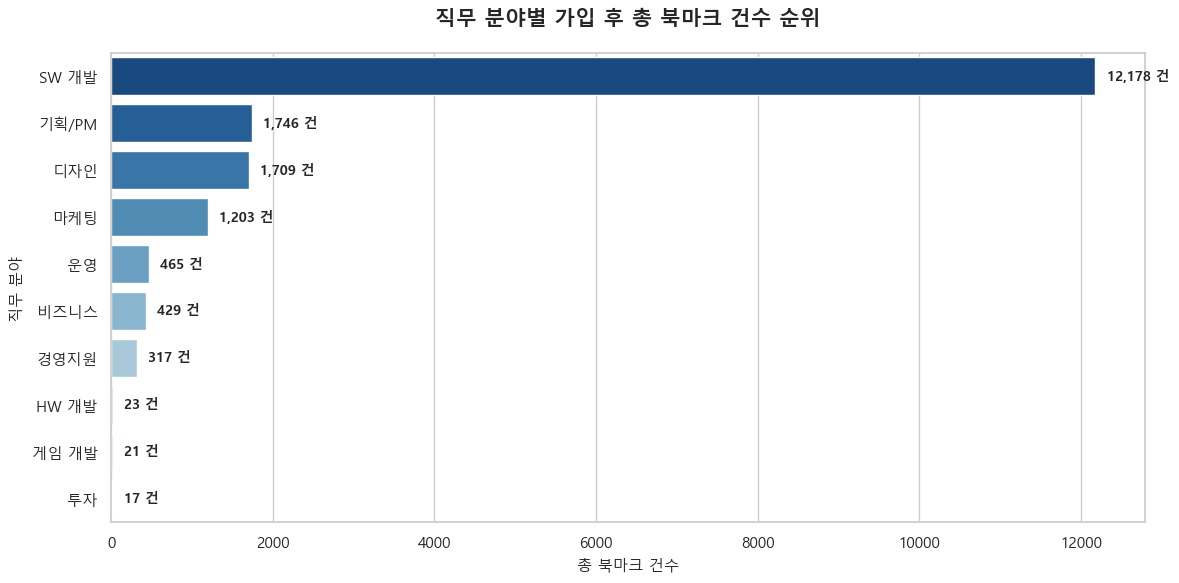

In [41]:
# 한글 깨짐 방지 및 스타일 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)
sns.set_theme(style="whitegrid", font="Malgun Gothic")

plt.figure(figsize=(12, 6))

# 가로 바 차트 생성 (데이터프레임 변수명: job_field_bookmark_stats)
ax = sns.barplot(
    data=job_field_bookmark_stats, 
    x='가입 후 총 북마크 건수', 
    y='직무 분야', 
    palette='Blues_r',
    hue='직무 분야',
    legend=False
)

# 막대 끝에 정확한 수치 표시 (가독성 보정)
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f'{int(width):,} 건', 
            (width, p.get_y() + p.get_height() / 2.),
            ha='left', 
            va='center', 
            xytext=(8, 0), 
            textcoords='offset points',
            fontsize=10, 
            weight='bold'
        )

# 차트 디테일 설정
plt.title('직무 분야별 가입 후 총 북마크 건수 순위', fontsize=15, weight='bold', pad=20)
plt.xlabel('총 북마크 건수', fontsize=11)
plt.ylabel('직무 분야', fontsize=11)

# 여백 조절 후 출력
plt.tight_layout()
plt.show()

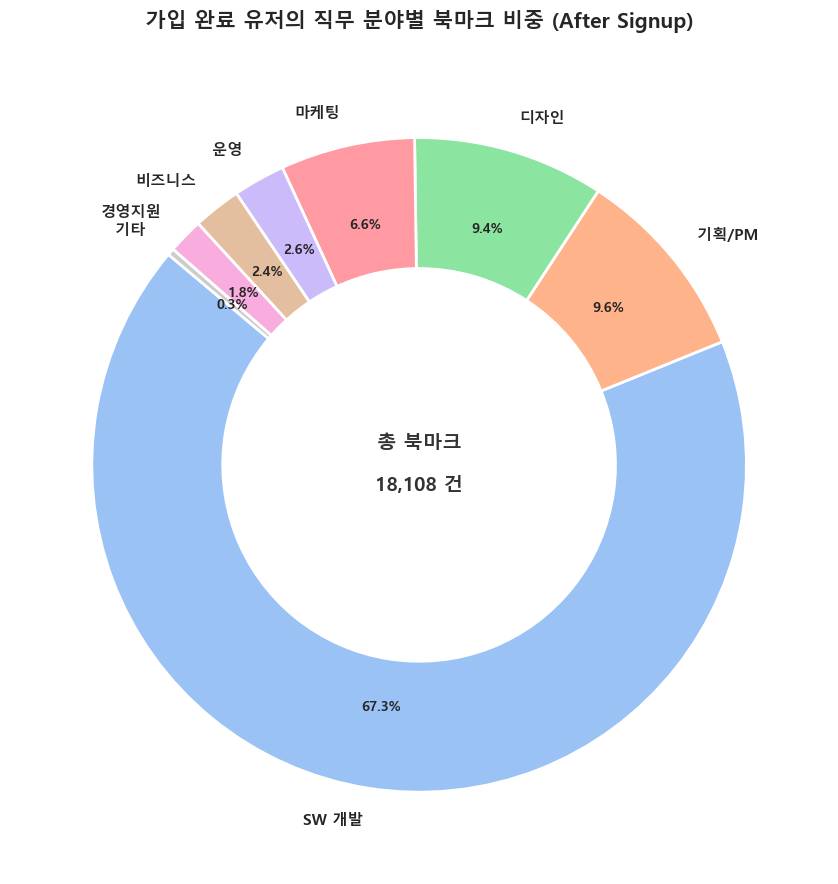

In [42]:
# 한글 깨짐 방지 및 스타일 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 2. 데이터 전처리: 시각화 가독성을 위해 상위 7개 외 나머지는 '기타'로 통합
df_pie = job_field_bookmark_stats.copy()

# 총 북마크 건수의 총합 계산 (도넛 중앙에 표시할 값)
total_bookmarks = df_pie['가입 후 총 북마크 건수'].sum()

# 상위 7개 직무 선정 및 나머지 기타 처리
top_n = 7
df_top = df_pie.iloc[:top_n].copy()
df_other = pd.DataFrame([{
    '직무 분야': '기타',
    '가입 후 총 북마크 건수': df_pie.iloc[top_n:]['가입 후 총 북마크 건수'].sum(),
    '북마크한 고유 유저 수': df_pie.iloc[top_n:]['북마크한 고유 유저 수'].nunique()
}])

df_final_pie = pd.concat([df_top, df_other], ignore_index=True)

# 3. 도넛 차트 그리기
fig, ax = plt.subplots(figsize=(9, 9))

# 스크린샷과 유사한 부드러운 파스텔톤 색상 매핑
colors = ['#9bc2f5', '#ffb38a', '#8ce4a1', '#ff9aa2', '#ccbbfb', '#e3be9f', '#f9addf', '#cccccc']

# 파이 차트 컴포넌트 생성
wedges, texts, autotexts = ax.pie(
    df_final_pie['가입 후 총 북마크 건수'], 
    labels=df_final_pie['직무 분야'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors[:len(df_final_pie)],
    wedgeprops=dict(width=0.4, edgecolor='w', linewidth=2), # width가 두께를 결정 (0.4 지정 시 도넛 형태)
    pctdistance=0.75
)

# 글꼴 스타일 및 가독성 조정
for text in texts:
    text.set_fontsize(11)
    text.set_weight('bold')
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_weight('bold')

# 도넛 중앙 구멍에 총 북마크 건수 텍스트 배치
ax.text(
    0, 0, 
    f'총 북마크\n\n{total_bookmarks:,} 건', 
    ha='center', 
    va='center', 
    fontsize=14, 
    weight='bold',
    color='#333333'
)

# 차트 제목 설정
plt.title('가입 완료 유저의 직무 분야별 북마크 비중 (After Signup)', fontsize=15, weight='bold', pad=20)

plt.tight_layout()
plt.show()

## 4. 인기 공고 특성 분석

### 4-1. 가입 유저가 가장 많이 지원한 공고 TOP 20

In [43]:
query = application_users_cte + """
SELECT 
    a.job_uuid,
    COUNT(DISTINCT a.user_uuid) AS applicant_count, -- 지원자 수 (순위 기준)
    j.job_field,                                   -- 직무 분야
    j.career_type_string,                           -- 경력 구분
    j.allow_remote,                                 -- 원격 근무 여부 (0 또는 1 등)
    j.can_show_salary,                              -- 연봉 공개 여부
    j.company_uuid,                                 -- 공고를 올린 회사 ID
    j.cdate                                         -- 공고 생성일
FROM application_users a
LEFT JOIN job j ON a.job_uuid = j.job_uuid
GROUP BY 
    a.job_uuid, 
    j.job_field, 
    j.career_type_string, 
    j.allow_remote, 
    j.can_show_salary, 
    j.company_uuid, 
    j.cdate
ORDER BY applicant_count DESC
LIMIT 20;
"""

top_jobs = pd.read_sql(query, engine)
# (데이터 보호: 원본 미리보기 출력 제거)
# top_jobs


In [44]:
query = application_users_cte + """
SELECT 
    a.job_uuid,
    COUNT(DISTINCT a.user_uuid) AS applicant_count, -- 지원자 수 (순위 기준)
    j.job_field,                                   -- 직무 분야
    j.career_type_string,                           -- 경력 구분
    j.allow_remote,                                 -- 원격 근무 여부
    j.can_show_salary,                              -- 연봉 공개 여부
    j.company_uuid,                                 -- 공고를 올린 회사 ID
    j.cdate,                                        -- 공고 생성일
    
    -- [추가] company 테이블의 주요 컬럼들을 오른쪽에 매핑
    c.employee_count,                               -- 회사 임직원 수
    c.view_count AS company_view_count,             -- 회사 페이지 조회수
    c.follow_count AS company_follow_count,         -- 회사 팔로우 수
    c.found_date AS company_found_date              -- 회사 설립일
FROM application_users a
LEFT JOIN job j ON a.job_uuid = j.job_uuid
LEFT JOIN company c ON j.company_uuid = c.company_uuid -- company 테이블 조인 추가
GROUP BY 
    a.job_uuid, 
    j.job_field, 
    j.career_type_string, 
    j.allow_remote, 
    j.can_show_salary, 
    j.company_uuid, 
    j.cdate,
    c.employee_count,
    c.view_count,
    c.follow_count,
    c.found_date
ORDER BY applicant_count DESC
LIMIT 20;
"""

top_jobs_company = pd.read_sql(query, engine)
# (데이터 보호: 원본 미리보기 출력 제거)
# top_jobs_company


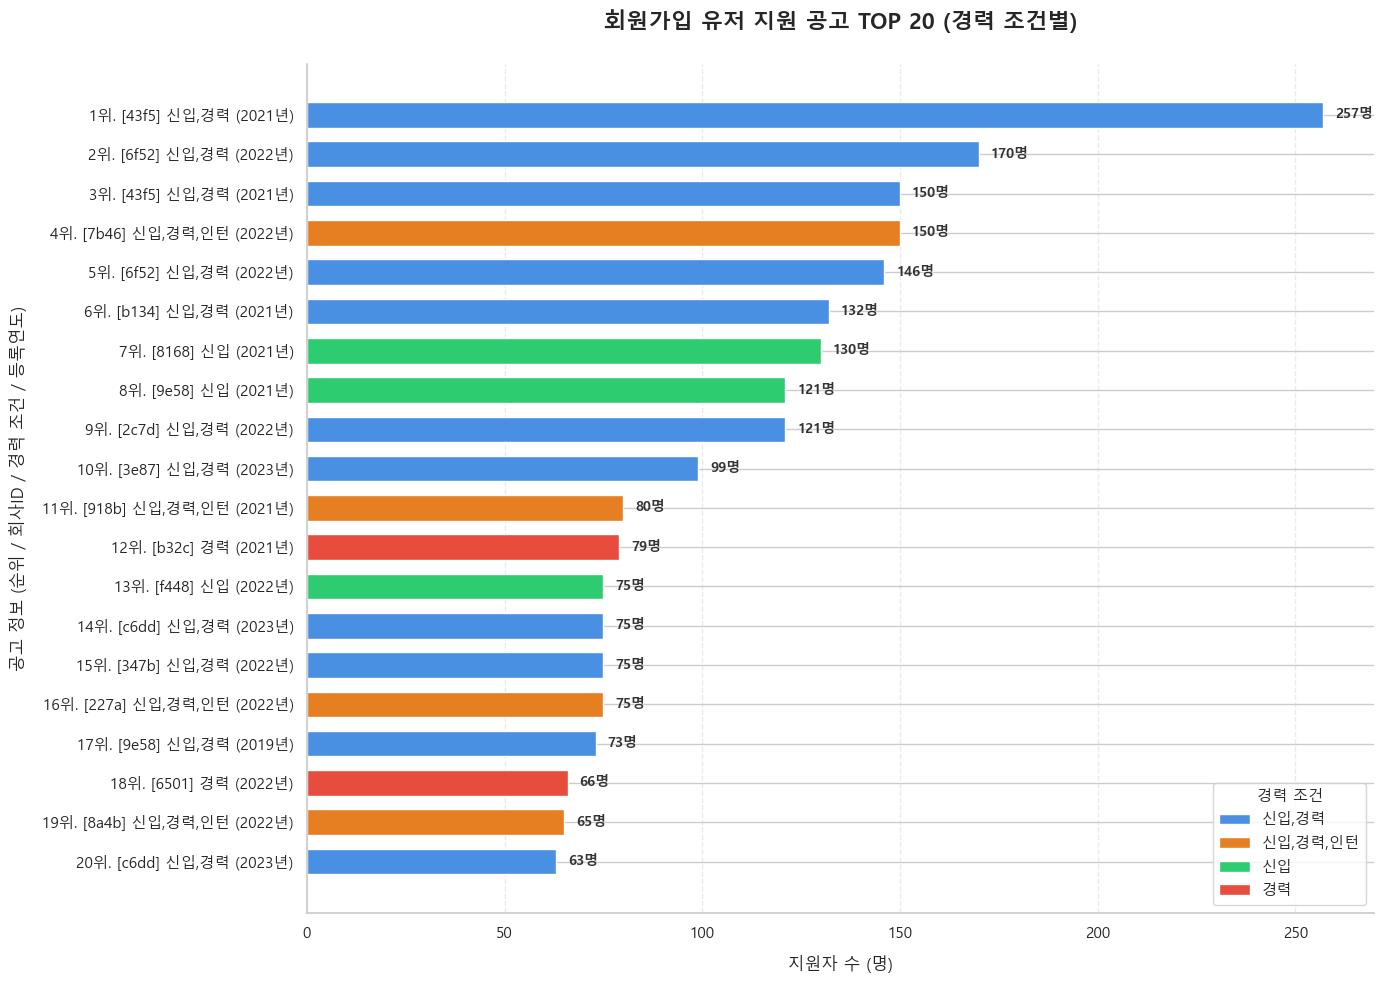

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터프레임 인덱스 초기화 및 고유 라벨 생성
top_jobs = top_jobs.reset_index(drop=True)
top_jobs['comp_short'] = top_jobs['company_uuid'].str[:4]
top_jobs['year'] = pd.to_datetime(top_jobs['cdate']).dt.year

top_jobs['plot_label'] = (
    (top_jobs.index + 1).astype(str) + "위. " 
    + "[" + top_jobs['comp_short'] + "] " 
    + top_jobs['career_type_string'] 
    + " (" + top_jobs['year'].astype(str) + "년)"
)

# 2. 경력 조건별 커스텀 색상 매핑 (Seaborn 'muted' 스타일 재현)
color_map = {
    '신입,경력': '#4A90E2',      # 블루
    '신입,경력,인턴': '#E67E22', # 오렌지
    '신입': '#2ECC71',          # 그린
    '경력': '#E74C3C'           # 레드
}
# 데이터프레임에 매칭되는 색상 컬럼 추가 (기본값은 회색)
colors = top_jobs['career_type_string'].map(color_map).fillna('#BDC3C7').tolist()

# 3. 플롯 스타일 및 크기 설정
plt.figure(figsize=(14, 10))
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 4. 순수 Matplotlib barh로 원본 데이터 그대로 그리기
bars = plt.barh(
    top_jobs['plot_label'].astype(str),
    top_jobs['applicant_count'],
    color=colors,  # 매핑된 색상 리스트 적용
    height=0.65
)

# 5. 레이아웃 및 디자인 디테일 (1등이 위로 가도록 설정)
plt.title('회원가입 유저 지원 공고 TOP 20 (경력 조건별)', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('지원자 수 (명)', fontsize=12, labelpad=10)
plt.ylabel('공고 정보 (순위 / 회사ID / 경력 조건 / 등록연도)', fontsize=12, labelpad=10)
plt.gca().invert_yaxis()  # 1위가 가장 위로 오게 뒤집기

# 바 오른쪽 끝에 정확한 지원자 수 수치 표시 (1위 자리에 257명)
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 3,
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}명',
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold',
        color='#333333'
    )

# 수동 범례(Legend) 추가
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=label) for label, color in color_map.items() if label in top_jobs['career_type_string'].unique()]
plt.legend(handles=legend_elements, title='경력 조건', title_fontsize='11', loc='lower right')

# 테두리 및 격자 정돈
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

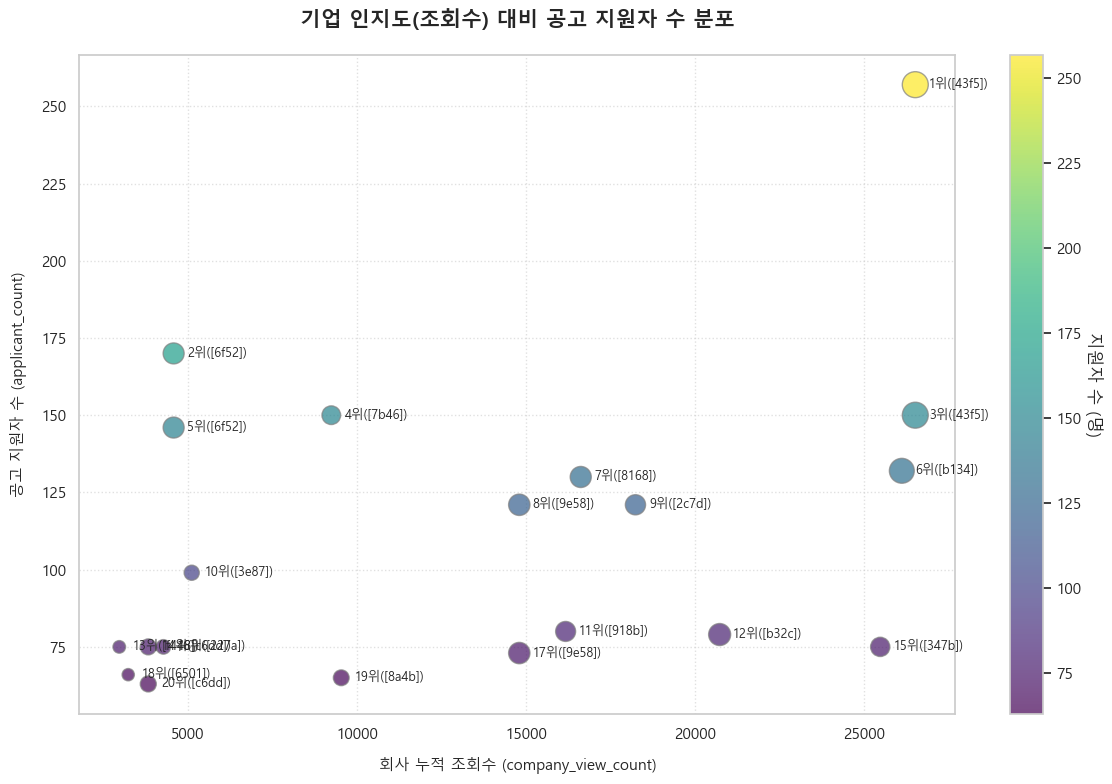

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 준비 및 회사 식별용 짧은 라벨 생성
df = top_jobs_company.copy().reset_index(drop=True)
df['comp_label'] = (df.index + 1).astype(str) + "위([" + df['company_uuid'].str[:4] + "])"

# 플롯 생성
plt.figure(figsize=(12, 8))
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 산점도 그리기 (원 크기를 팔로우 수에 비례하게 설정하여 3차원 데이터 표현)
# 팔로우 수가 많을수록 원이 커집니다.
point_sizes = (df['company_follow_count'] / df['company_follow_count'].max() * 300) + 50

scatter = plt.scatter(
    df['company_view_count'], 
    df['applicant_count'], 
    s=point_sizes, 
    c=df['applicant_count'], # 지원자 수에 따라 색상 변경
    cmap='viridis', 
    alpha=0.7, 
    edgecolors='gray'
)

# 각 점 옆에 공고 순위와 회사 ID 라벨 달아주기
for i, txt in enumerate(df['comp_label']):
    plt.text(
        df['company_view_count'].iloc[i] + (df['company_view_count'].max() * 0.015), 
        df['applicant_count'].iloc[i], 
        txt, 
        fontsize=9, 
        va='center'
    )

# 차트 디테일
plt.title('기업 인지도(조회수) 대비 공고 지원자 수 분포', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('회사 누적 조회수 (company_view_count)', fontsize=11, labelpad=10)
plt.ylabel('공고 지원자 수 (applicant_count)', fontsize=11, labelpad=10)
plt.grid(True, linestyle=':', alpha=0.6)

# 컬러바 추가
cbar = plt.colorbar(scatter)
cbar.set_label('지원자 수 (명)', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

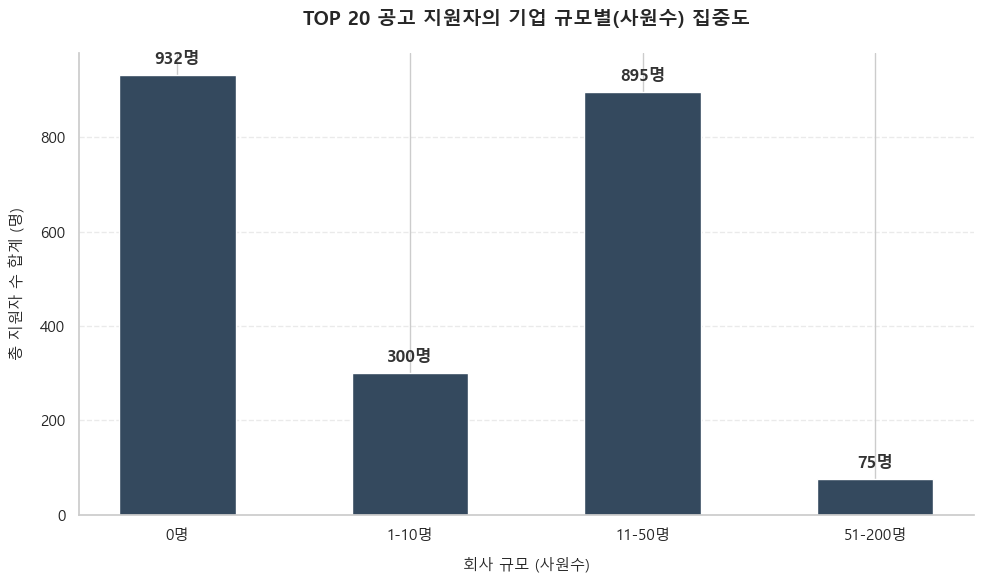

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

df = top_jobs_company.copy()

# 1. 회사 규모(employee_count)별로 지원자 수 합계 집계
# 원래 순서대로 정렬하기 위해 카테고리 순서 정의 (데이터에 존재하는 값 기준)
size_order = ['0명', '1-10명', '11-50명', '51-200명']
summary = df.groupby('employee_count')['applicant_count'].sum().reindex(size_order).dropna().reset_index()

# 2. 플롯 생성
plt.figure(figsize=(10, 6))

bars = plt.bar(
    summary['employee_count'],
    summary['applicant_count'],
    color='#34495E',
    width=0.5
)

# 디테일 수정
plt.title('TOP 20 공고 지원자의 기업 규모별(사원수) 집중도', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('회사 규모 (사원수)', fontsize=11, labelpad=10)
plt.ylabel('총 지원자 수 합계 (명)', fontsize=11, labelpad=10)

# 바 위에 수치 표시
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 15,
        f'{int(height)}명',
        ha='center',
        va='bottom',
        fontweight='bold',
        color='#333333'
    )

# 테두리 정리
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

### 4-2. 직무 / 경력 / 원격근무 / 연봉공개 여부별 지원 집중도

In [48]:
query = application_users_cte + """
, popular_jobs AS (
    SELECT
        job_uuid,
        COUNT(DISTINCT user_uuid) AS applicant_count
    FROM application_users
    GROUP BY job_uuid
)

SELECT
    p.job_uuid,
    p.applicant_count,
    j.job_field,
    j.career_type_string,
    j.allow_remote,
    j.can_show_salary
FROM popular_jobs p
JOIN Job j
    ON p.job_uuid = j.job_uuid
"""

job_feature = pd.read_sql(query, engine)

# (데이터 보호: 원본 미리보기 출력 제거)
# job_feature.head()


### 직무별 인기

In [49]:
job_feature.groupby(
    'job_field'
)['applicant_count'].agg(
    공고수='count',
    평균지원자수='mean'
).sort_values(
    '평균지원자수',
    ascending=False
)

### 경력별 인기

In [50]:
job_feature.groupby(
    'career_type_string'
)['applicant_count'].agg(
    공고수='count',
    평균지원자수='mean'
).sort_values(
    '평균지원자수',
    ascending=False
)

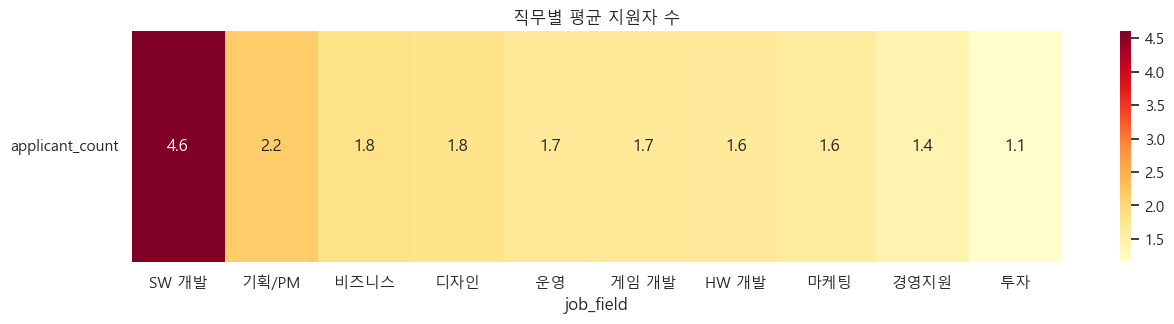

In [51]:
job_field_heat = (
    job_feature.groupby('job_field')['applicant_count']
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .to_frame()
    .T
)

plt.figure(figsize=(15,3))

sns.heatmap(
    job_field_heat,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd'
)

plt.title('직무별 평균 지원자 수')
plt.yticks(rotation=0)

plt.show()

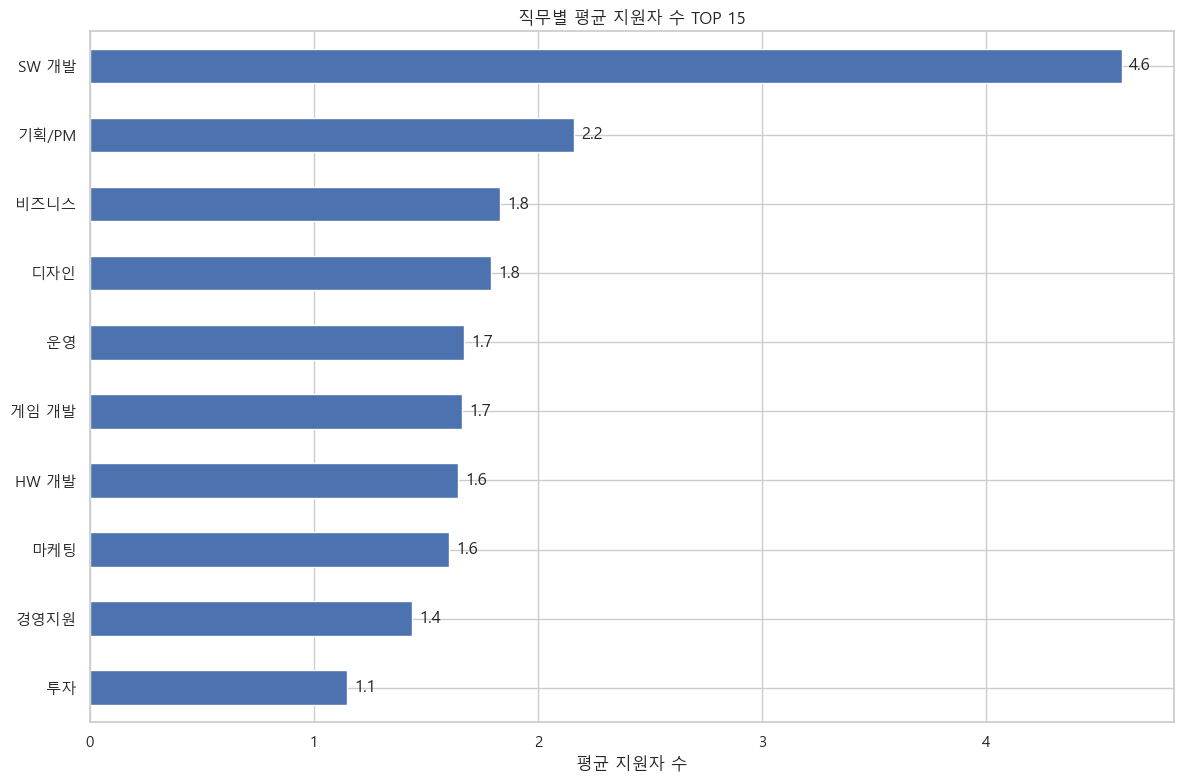

In [52]:
job_field_result = (
    job_feature.groupby('job_field')['applicant_count']
    .mean()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 8))

job_field_result.tail(15).plot(
    kind='barh',
    ax=ax
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f',
        padding=5
    )

ax.set_xlabel('평균 지원자 수')
ax.set_ylabel('')
ax.set_title('직무별 평균 지원자 수 TOP 15')

plt.tight_layout()
plt.show()

### 원격근무별 인기

In [53]:
job_feature.groupby(
    'allow_remote'
)['applicant_count'].agg(
    공고수='count',
    평균지원자수='mean'
)

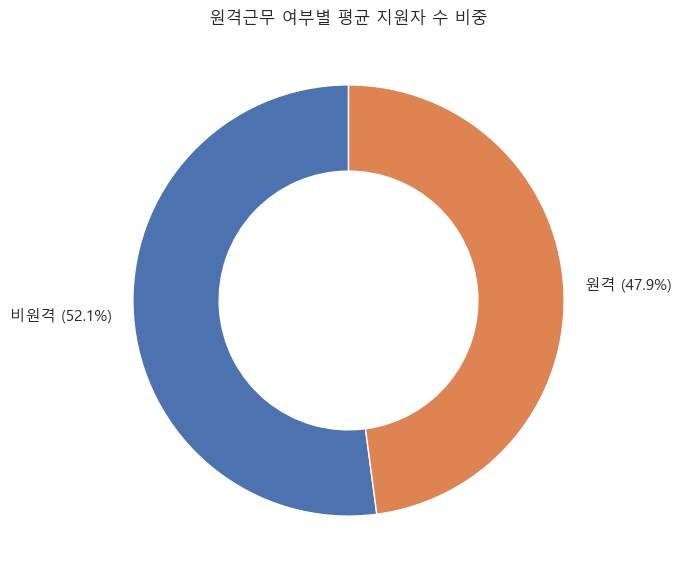

In [54]:
remote = (
    job_feature.groupby('allow_remote')['applicant_count']
    .mean()
)

labels = [
    f'비원격 ({remote.iloc[0]/remote.sum()*100:.1f}%)',
    f'원격 ({remote.iloc[1]/remote.sum()*100:.1f}%)'
]

fig, ax = plt.subplots(figsize=(7,7))

ax.pie(
    remote,
    labels=labels,
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title('원격근무 여부별 평균 지원자 수 비중')
plt.show()

### 연봉공개별 인기

In [55]:
job_feature.groupby(
    'can_show_salary'
)['applicant_count'].agg(
    공고수='count',
    평균지원자수='mean'
)

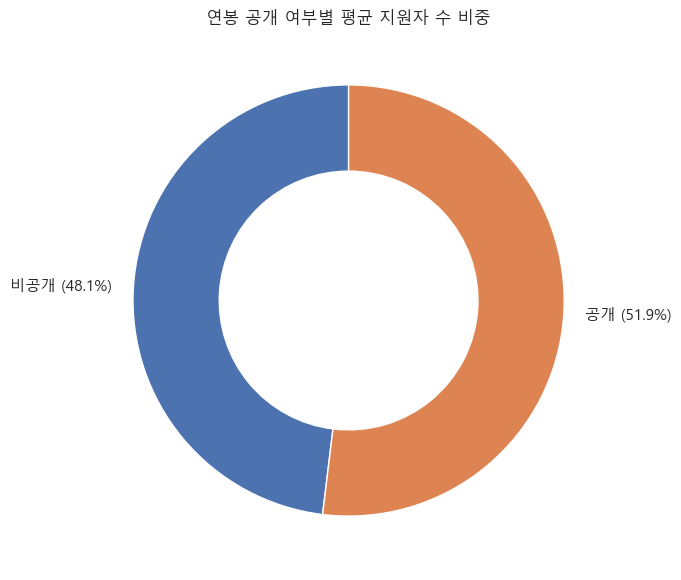

In [56]:
salary = (
    job_feature.groupby('can_show_salary')['applicant_count']
    .mean()
)

labels = [
    f'비공개 ({salary.iloc[0]/salary.sum()*100:.1f}%)',
    f'공개 ({salary.iloc[1]/salary.sum()*100:.1f}%)'
]

fig, ax = plt.subplots(figsize=(7,7))

ax.pie(
    salary,
    labels=labels,
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title('연봉 공개 여부별 평균 지원자 수 비중')
plt.show()

### 해석
- sw개발 직군에 수요가 매우 강하게 집중됨
- 지원자는 신입 지원자의 중심이 큼(경력 대비 1.8배)
- 원격근무 여부는 크게 차이 없음
- 연봉 공개 : 긍정적 효과(약 8% 차이)

- 결론
    - 영향력 크기 순서 : 직무 > 경력 조건 > 연봉 공개 > 원격근무
    - 인기공고 특징 : sw개발 + 신입 가능 + 연봉 공개

## 5. 기간별 행동 변화 (7 / 30 / 60 / 90일)

가입 후 행동을 7일, 30일, 60일, 90일 기준으로 비교

데이터가 2023-12-31까지라서 가입 후 90일치 행동을 모두 관찰할 수 있는 유저만 확인

2023년 10월 이후 가입자는 분석에서 제외

행동 기준은 다음과 같이 분리함

- 공고 탐색 / 회사 탐색 / 검색: `post_signup_logs` 기준
- 북마크: `JobBookmark` 테이블 기준
- 지원: `Application` 테이블 기준

In [57]:
DATA_END = "2023-12-31 23:59:59"
MAX_WINDOW = 90

query = post_signup_cte + f"""
,
signup_users AS (
    SELECT
        user_uuid,
        done_time
    FROM step3_done_users
    WHERE done_time <= DATE_SUB('{DATA_END}', INTERVAL {MAX_WINDOW} DAY)
),

log_action_counts AS (
    SELECT
        s.user_uuid,

        -- 7일 기준 일반 행동로그
        SUM(CASE WHEN p.timestamp <= DATE_ADD(s.done_time, INTERVAL 7 DAY) AND p.url_path LIKE '%%job%%' THEN 1 ELSE 0 END) AS job_7,
        SUM(CASE WHEN p.timestamp <= DATE_ADD(s.done_time, INTERVAL 7 DAY) AND p.url_path LIKE '%%company%%' THEN 1 ELSE 0 END) AS company_7,
        SUM(CASE WHEN p.timestamp <= DATE_ADD(s.done_time, INTERVAL 7 DAY) AND p.url_path LIKE '%%search%%' THEN 1 ELSE 0 END) AS search_7,

        -- 30일 기준 일반 행동로그
        SUM(CASE WHEN p.timestamp <= DATE_ADD(s.done_time, INTERVAL 30 DAY) AND p.url_path LIKE '%%job%%' THEN 1 ELSE 0 END) AS job_30,
        SUM(CASE WHEN p.timestamp <= DATE_ADD(s.done_time, INTERVAL 30 DAY) AND p.url_path LIKE '%%company%%' THEN 1 ELSE 0 END) AS company_30,
        SUM(CASE WHEN p.timestamp <= DATE_ADD(s.done_time, INTERVAL 30 DAY) AND p.url_path LIKE '%%search%%' THEN 1 ELSE 0 END) AS search_30,

        -- 60일 기준 일반 행동로그
        SUM(CASE WHEN p.timestamp <= DATE_ADD(s.done_time, INTERVAL 60 DAY) AND p.url_path LIKE '%%job%%' THEN 1 ELSE 0 END) AS job_60,
        SUM(CASE WHEN p.timestamp <= DATE_ADD(s.done_time, INTERVAL 60 DAY) AND p.url_path LIKE '%%company%%' THEN 1 ELSE 0 END) AS company_60,
        SUM(CASE WHEN p.timestamp <= DATE_ADD(s.done_time, INTERVAL 60 DAY) AND p.url_path LIKE '%%search%%' THEN 1 ELSE 0 END) AS search_60,

        -- 90일 기준 일반 행동로그
        SUM(CASE WHEN p.timestamp <= DATE_ADD(s.done_time, INTERVAL 90 DAY) AND p.url_path LIKE '%%job%%' THEN 1 ELSE 0 END) AS job_90,
        SUM(CASE WHEN p.timestamp <= DATE_ADD(s.done_time, INTERVAL 90 DAY) AND p.url_path LIKE '%%company%%' THEN 1 ELSE 0 END) AS company_90,
        SUM(CASE WHEN p.timestamp <= DATE_ADD(s.done_time, INTERVAL 90 DAY) AND p.url_path LIKE '%%search%%' THEN 1 ELSE 0 END) AS search_90

    FROM signup_users s
    LEFT JOIN post_signup_logs p
        ON s.user_uuid = p.user_uuid
       AND p.timestamp <= DATE_ADD(s.done_time, INTERVAL 90 DAY)
    GROUP BY s.user_uuid
),

bookmark_counts AS (
    SELECT
        s.user_uuid,

        -- 가입 완료 이후 북마크한 공고 수
        COUNT(DISTINCT CASE WHEN b.first_bm_time <= DATE_ADD(s.done_time, INTERVAL 7 DAY) THEN b.job_uuid END) AS bookmark_7,
        COUNT(DISTINCT CASE WHEN b.first_bm_time <= DATE_ADD(s.done_time, INTERVAL 30 DAY) THEN b.job_uuid END) AS bookmark_30,
        COUNT(DISTINCT CASE WHEN b.first_bm_time <= DATE_ADD(s.done_time, INTERVAL 60 DAY) THEN b.job_uuid END) AS bookmark_60,
        COUNT(DISTINCT CASE WHEN b.first_bm_time <= DATE_ADD(s.done_time, INTERVAL 90 DAY) THEN b.job_uuid END) AS bookmark_90

    FROM signup_users s
    LEFT JOIN bookmark_users b
        ON s.user_uuid = b.user_uuid
       AND b.first_bm_time <= DATE_ADD(s.done_time, INTERVAL 90 DAY)
    GROUP BY s.user_uuid
),

application_counts AS (
    SELECT
        s.user_uuid,

        -- 가입 완료 이후 지원한 공고 수
        COUNT(DISTINCT CASE WHEN a.first_apply_time <= DATE_ADD(s.done_time, INTERVAL 7 DAY) THEN a.job_uuid END) AS application_7,
        COUNT(DISTINCT CASE WHEN a.first_apply_time <= DATE_ADD(s.done_time, INTERVAL 30 DAY) THEN a.job_uuid END) AS application_30,
        COUNT(DISTINCT CASE WHEN a.first_apply_time <= DATE_ADD(s.done_time, INTERVAL 60 DAY) THEN a.job_uuid END) AS application_60,
        COUNT(DISTINCT CASE WHEN a.first_apply_time <= DATE_ADD(s.done_time, INTERVAL 90 DAY) THEN a.job_uuid END) AS application_90

    FROM signup_users s
    LEFT JOIN application_users a
        ON s.user_uuid = a.user_uuid
       AND a.first_apply_time <= DATE_ADD(s.done_time, INTERVAL 90 DAY)
    GROUP BY s.user_uuid
)

SELECT
    s.user_uuid,
    s.done_time,

    COALESCE(l.job_7, 0) AS job_7,
    COALESCE(l.company_7, 0) AS company_7,
    COALESCE(l.search_7, 0) AS search_7,
    COALESCE(b.bookmark_7, 0) AS bookmark_7,
    COALESCE(a.application_7, 0) AS application_7,

    COALESCE(l.job_30, 0) AS job_30,
    COALESCE(l.company_30, 0) AS company_30,
    COALESCE(l.search_30, 0) AS search_30,
    COALESCE(b.bookmark_30, 0) AS bookmark_30,
    COALESCE(a.application_30, 0) AS application_30,

    COALESCE(l.job_60, 0) AS job_60,
    COALESCE(l.company_60, 0) AS company_60,
    COALESCE(l.search_60, 0) AS search_60,
    COALESCE(b.bookmark_60, 0) AS bookmark_60,
    COALESCE(a.application_60, 0) AS application_60,

    COALESCE(l.job_90, 0) AS job_90,
    COALESCE(l.company_90, 0) AS company_90,
    COALESCE(l.search_90, 0) AS search_90,
    COALESCE(b.bookmark_90, 0) AS bookmark_90,
    COALESCE(a.application_90, 0) AS application_90

FROM signup_users s
LEFT JOIN log_action_counts l
    ON s.user_uuid = l.user_uuid
LEFT JOIN bookmark_counts b
    ON s.user_uuid = b.user_uuid
LEFT JOIN application_counts a
    ON s.user_uuid = a.user_uuid;
"""

df_post_all = pd.read_sql(query, engine)
# (데이터 보호: 원본 미리보기 출력 제거)
# df_post_all.head()


In [58]:
# 가입 후 기간별 핵심 행동
windows = [7, 30, 60, 90]

summary_list = []

for days in windows:
    total_users = df_post_all['user_uuid'].nunique()
    
    summary_list.append({
        '기준기간': f'{days}일',
        '가입완료유저수': total_users,

        '공고로그_유저비율': round((df_post_all[f'job_{days}'] > 0).mean() * 100, 2),
        '회사로그_유저비율': round((df_post_all[f'company_{days}'] > 0).mean() * 100, 2),
        '검색로그_유저비율': round((df_post_all[f'search_{days}'] > 0).mean() * 100, 2),
        '북마크_유저비율': round((df_post_all[f'bookmark_{days}'] > 0).mean() * 100, 2),
        '지원_유저비율': round((df_post_all[f'application_{days}'] > 0).mean() * 100, 2),

        '전체평균_북마크공고수': round(df_post_all[f'bookmark_{days}'].mean(), 2),
        '전체평균_지원공고수': round(df_post_all[f'application_{days}'].mean(), 2),

        '북마크유저기준_평균북마크공고수': round(
            df_post_all.loc[df_post_all[f'bookmark_{days}'] > 0, f'bookmark_{days}'].mean(), 2
        ),
        '지원유저기준_평균지원공고수': round(
            df_post_all.loc[df_post_all[f'application_{days}'] > 0, f'application_{days}'].mean(), 2
        )
    })

df_period_summary = pd.DataFrame(summary_list)
df_period_summary


### 5-1. 기간별 핵심 행동 경험률 추이

In [59]:
action_rate = df_period_summary[
    [
        '기준기간',
        '공고로그_유저비율',
        '회사로그_유저비율',
        '검색로그_유저비율',
        '북마크_유저비율',
        '지원_유저비율'
    ]
].copy()

action_rate

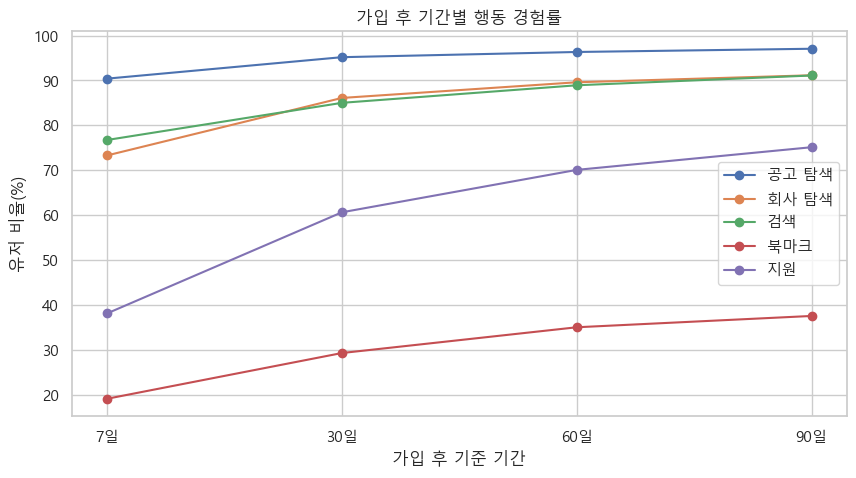

In [60]:
plt.figure(figsize=(10, 5))

plt.plot(action_rate['기준기간'], action_rate['공고로그_유저비율'], marker='o', label='공고 탐색')
plt.plot(action_rate['기준기간'], action_rate['회사로그_유저비율'], marker='o', label='회사 탐색')
plt.plot(action_rate['기준기간'], action_rate['검색로그_유저비율'], marker='o', label='검색')
plt.plot(action_rate['기준기간'], action_rate['북마크_유저비율'], marker='o', label='북마크')
plt.plot(action_rate['기준기간'], action_rate['지원_유저비율'], marker='o', label='지원')

plt.title('가입 후 기간별 행동 경험률')
plt.xlabel('가입 후 기준 기간')
plt.ylabel('유저 비율(%)')
plt.legend()
plt.show()

### 해석

가입 후 기간이 길어질수록 행동 경험은 증가하는 흐름을 볼 수 있음

공고 탐색 / 회사 탐색 / 검색은 가입 완료 이후 의미있는 로그 기준으로 봤고,
북마크와 지원은 각각 `JobBookmark`, `Application` 테이블 기준으로 봤음

### 5-2. 기간별 북마크 및 지원 유저 비율 변화

In [61]:
df_bookmark_apply_period = df_period_summary[
    [
        '기준기간',
        '북마크_유저비율',
        '지원_유저비율',
        '전체평균_북마크공고수',
        '전체평균_지원공고수'
    ]
].copy()

df_bookmark_apply_period

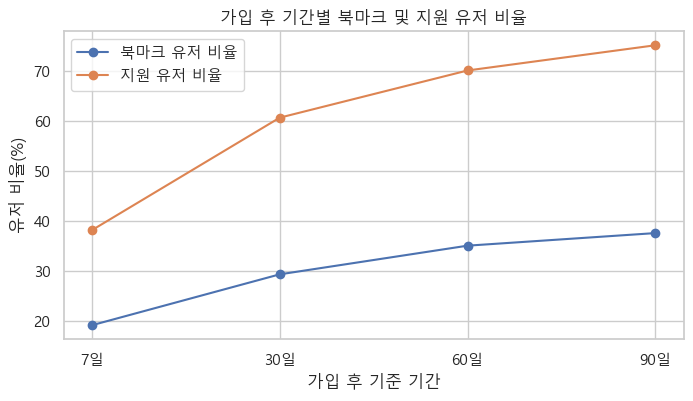

In [62]:
plt.figure(figsize=(8, 4))

plt.plot(
    df_bookmark_apply_period['기준기간'],
    df_bookmark_apply_period['북마크_유저비율'],
    marker='o',
    label='북마크 유저 비율'
)

plt.plot(
    df_bookmark_apply_period['기준기간'],
    df_bookmark_apply_period['지원_유저비율'],
    marker='o',
    label='지원 유저 비율'
)

plt.title('가입 후 기간별 북마크 및 지원 유저 비율')
plt.xlabel('가입 후 기준 기간')
plt.ylabel('유저 비율(%)')
plt.legend()
plt.show()

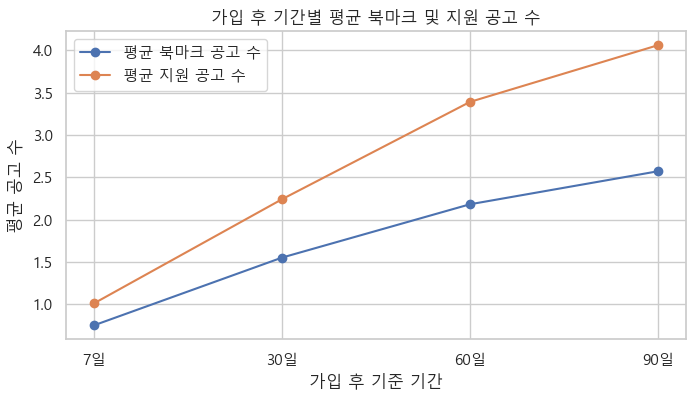

In [63]:
plt.figure(figsize=(8, 4))

plt.plot(
    df_bookmark_apply_period['기준기간'],
    df_bookmark_apply_period['전체평균_북마크공고수'],
    marker='o',
    label='평균 북마크 공고 수'
)

plt.plot(
    df_bookmark_apply_period['기준기간'],
    df_bookmark_apply_period['전체평균_지원공고수'],
    marker='o',
    label='평균 지원 공고 수'
)

plt.title('가입 후 기간별 평균 북마크 및 지원 공고 수')
plt.xlabel('가입 후 기준 기간')
plt.ylabel('평균 공고 수')
plt.legend()
plt.show()

### 5-3. 90일 기준 지원 여부별 행동 비교

In [64]:
df_post_90 = df_post_all.copy()

count_cols = ['job_90', 'company_90', 'search_90', 'bookmark_90', 'application_90']
df_post_90[count_cols] = df_post_90[count_cols].fillna(0)

df_post_90['has_application_90'] = (df_post_90['application_90'] > 0).astype(int)

df_apply_compare_90 = (
    df_post_90
    .groupby('has_application_90')
    .agg(
        users=('user_uuid', 'nunique'),
        avg_job_logs=('job_90', 'mean'),
        avg_company_logs=('company_90', 'mean'),
        avg_search_logs=('search_90', 'mean'),
        avg_bookmark_count=('bookmark_90', 'mean'),
        avg_application_count=('application_90', 'mean')
    )
    .reset_index()
)

df_apply_compare_90['지원여부'] = df_apply_compare_90['has_application_90'].map({
    0: '지원 안 함',
    1: '지원 함'
})

df_apply_compare_90[
    [
        '지원여부',
        'users',
        'avg_job_logs',
        'avg_company_logs',
        'avg_search_logs',
        'avg_bookmark_count',
        'avg_application_count'
    ]
].round(2)

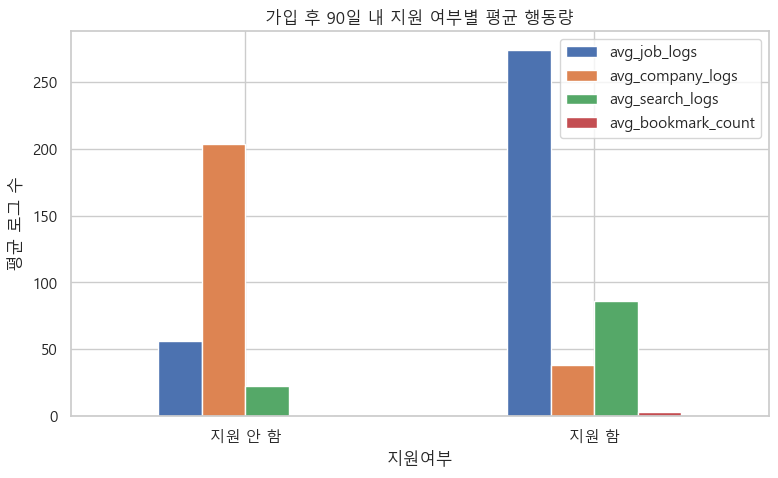

In [65]:
compare_cols = [
    'avg_job_logs',
    'avg_company_logs',
    'avg_search_logs',
    'avg_bookmark_count'
]

df_apply_compare_plot = df_apply_compare_90.set_index('지원여부')[compare_cols]

df_apply_compare_plot.plot(kind='bar', figsize=(9, 5))

plt.title('가입 후 90일 내 지원 여부별 평균 행동량')
plt.ylabel('평균 로그 수')
plt.xticks(rotation=0)
plt.show()

## 6. 종합 요약 및 인사이트

### 6-1. 핵심 발견

- **지원 퍼널**: 공고조회 → 지원페이지 → 실제 지원 사이의 이탈은 크지 않다.
- **첫 지원 소요 시간**: 중앙값 13.3일(약 2주)이지만 평균은 62.2일(약 2개월)까지 늘어난다. 약 20.6%는 가입 후 3개월이 지나서야 첫 지원을 한다.
- **첫 행동과 지원 성향**: 가입 직후 프로필을 먼저 편집한 유저의 평균 지원 횟수(8.16회)가 공고를 먼저 조회한 유저(5.49회)보다 뚜렷하게 높다.
- **지원 횟수 분포**: 가입 완료 유저의 95.8%가 최소 1회 이상 지원하며, 평균 6.96회·중앙값 3회로 소수의 다회 지원자가 평균을 끌어올린다.
- **북마크-지원 관계**: 북마크만 하고 지원하지 않는 유저는 거의 없다 — 북마크는 지원을 대체하기보다 보조하는 역할을 한다. 가입 후 완전히 이탈하는 비율도 매우 낮다.
- **인기 공고 특성**: 영향력 순서는 직무 > 경력 조건 > 연봉 공개 > 원격근무이며, SW개발·신입 가능·연봉 공개 공고에 지원이 집중된다.
- **기간별 행동 변화**: 가입 후 경과 기간이 길어질수록(7→90일) 공고/회사 탐색, 검색, 북마크, 지원 등 모든 행동의 경험률이 함께 증가한다.

### 6-2. 제언

| 우선순위 | 액션 | 근거 |
|---|---|---|
| ★★★ | 가입 직후 프로필 작성 유도(온보딩 넛지) | 프로필 편집을 먼저 한 유저의 지원 횟수가 1.5배 높음 |
| ★★ | 가입 후 1~2주 내 재방문 유도 알림 | 첫 지원까지 중앙값 13.3일, 3개월 초과자도 20% 존재 |
| ★★ | SW개발·신입 가능·연봉 공개 공고 노출 강화 | 지원 집중도가 가장 높은 공고 특성 |
| ★ | 북마크 후 미지원 유저 대상 리마인드 | 북마크는 지원의 보조 신호로 작동 |
